# 33 — Butina cluster-disjoint CV: does the split scheme change any conclusion?

**Cold-start summary.** Every CV result in this project uses the frozen random 5x5
partition in `data/folds/cv_folds.csv`. Four CV-confirmed results have failed to
transfer to the blind board (08's ensembles, NB10/NB12, NB29→NB30, NB31→NB32-A). Three
entrants placed above this project use cluster-disjoint folds instead of random ones,
and one (lachrymator) states plainly that Butina folds made held-out numbers track the
leaderboard where random splits did not. Pat Walters confirmed on the challenge Discord
(2026-09-10) that CYP3A4's screening set was built by Butina-clustering (2048-bit Morgan
radius=3, Tanimoto **distance** cutoff 0.65) and pairing each qualifying top-activity
compound with one random cluster-mate — "pairing the most active compounds with
structurally related but less active analogs." He does not confirm the same recipe for
the other three isoforms.

**This notebook builds a cluster-disjoint 5-fold (one repeat) partition using that exact
recipe, checks how different it is from the random partition before training anything,
regenerates out-of-fold Chemprop predictions on the new partition only (the random side
is reused read-only from notebooks 05/29, which already hold `repeat_0`'s five folds for
exactly this architecture), adds a frozen-CheMeleon-embedding tabular head, and reports
whether any conclusion changes.**

**Read-only with respect to every existing artifact.** `data/folds/cv_folds.csv` is
never modified; the new partition is written to `data/folds/cv_folds_butina.csv`. No
submission, no ensemble, no full-data retrain, no retest of any prior screen.

**Honest prior, stated before any computation**: notebook 02 found 96.4% of Bemis-Murcko
scaffolds are singletons in this training set; an entrant reports 93.6% of Butina
clusters are singletons on (per the task brief) the same data. If nearly every compound
is its own cluster, cluster-disjoint folds should differ from random folds for only a
small minority of compounds. **Part 1 below finds this prior does not hold** for the
specific radius=3/distance=0.65 recipe confirmed for this challenge — stated plainly as
a real, unanticipated finding, not smoothed over.

**Autonomy.** Any specification gap is resolved by the most literal reading of the task
brief, or, failing that, the option that changes least from this project's existing
conventions (notebooks 05b/28/29). Every such choice is recorded in the **"Decisions
taken without approval"** section near the end, present even if empty.


In [1]:

import os
os.environ.setdefault("OMP_NUM_THREADS", "1")
os.environ.setdefault("KMP_DUPLICATE_LIB_OK", "TRUE")

import sys
from pathlib import Path

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(REPO_ROOT))

import hashlib
import importlib.metadata
import itertools
import json
import subprocess
import time
from datetime import datetime, timezone

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from rdkit import Chem, DataStructs
from rdkit.Chem import rdFingerprintGenerator
from scipy import stats
from scipy.optimize import linear_sum_assignment

from src.features import (
    butina_clusters,
    canonicalize_smiles,
    ecfp4_fingerprints,
    nearest_neighbor_similarity,
    smiles_to_inchikey,
    assign_screen_split,
)
from src.chemprop_screen import (
    build_predict_csv,
    build_training_csv,
    run_chemprop_predict,
    run_chemprop_train,
    setup_logging,
    verify_predictions,
)
from src.cv_bootstrap import per_fold_bootstrap_seed
from src.vendor.openadmet_eval.config import ACTIVITY_METRICS, REGRESSION_ENDPOINTS
from src.vendor.openadmet_eval.evaluate_predictions import add_macro_endpoint, score_activity_predictions

print(f"python: {sys.version.split()[0]}")
for pkg in ["numpy", "pandas", "scipy", "matplotlib", "rdkit", "chemprop", "torch", "scikit-learn", "lightgbm"]:
    try:
        print(f"{pkg}: {importlib.metadata.version(pkg)}")
    except importlib.metadata.PackageNotFoundError:
        pass

METRIC_NAMES = [name for name, _ in ACTIVITY_METRICS]
ISOFORMS = [e.split("_")[0] for e in REGRESSION_ENDPOINTS]
PIC50_COL = {iso: f"{iso}_pIC50_direct_inhibition" for iso in ISOFORMS}
AUX_COLS = [f"{iso}_AID1851_max_inhibition" for iso in ISOFORMS]
PANEL_TO_ISOFORM = {
    "p450-cyp1a2": "CYP1A2", "p450-cyp2c9": "CYP2C9",
    "p450-cyp2d6": "CYP2D6", "p450-cyp3a4": "CYP3A4",
}

OUT = REPO_ROOT / "outputs" / "33_butina_split"
FIG_OUT = OUT / "figures"
CHEMPROP_RUNS_DIR = OUT / "chemprop_runs"
PRED_DIR = OUT / "predictions"
SCORE_DIR = OUT / "scores"
OOF_DIR = OUT / "oof_long"
LOG_DIR = REPO_ROOT / "logs" / "33_butina_split"
for d in [OUT, FIG_OUT, CHEMPROP_RUNS_DIR, PRED_DIR, SCORE_DIR, OOF_DIR, LOG_DIR]:
    d.mkdir(parents=True, exist_ok=True)

FOLDS_PATH = REPO_ROOT / "data" / "folds" / "cv_folds.csv"                    # READ-ONLY, never modified
BUTINA_FOLDS_PATH = REPO_ROOT / "data" / "folds" / "cv_folds_butina.csv"      # NEW file this notebook writes
CURATED_PATH = REPO_ROOT / "data" / "processed" / "train_inhibition_curated.csv"
BLIND_PATH = REPO_ROOT / "data" / "processed" / "test_blinded_curated.csv"
AID_CURATED_PATH = REPO_ROOT / "data" / "processed" / "aid1851_curated.csv"
AID_RAW_DIR = REPO_ROOT / "data" / "raw" / "aid1851"
NB28_OUT = REPO_ROOT / "outputs" / "28_external_data"
NB29_OUT = REPO_ROOT / "outputs" / "29_cv_confirmation"
NB05_OUT = REPO_ROOT / "outputs" / "05_cv_comparison"
NB24_OUT = REPO_ROOT / "outputs" / "24_nonnegative_stacking"
MANIFEST_PATH = NB05_OUT / "manifest.csv"
CHEMELEON_EMB_PATH = REPO_ROOT / "data" / "processed" / "chemeleon_embeddings.npy"
CHEMELEON_IDX_PATH = REPO_ROOT / "data" / "processed" / "chemeleon_embeddings_index.csv"
ECFP4_NARROW_PATH = REPO_ROOT / "data" / "processed" / "tabular_baseline_features.csv"
LEADERBOARD_DOC_PATH = REPO_ROOT / "docs" / "leaderboard_submissions.md"

VAL_FRACTION = 0.15
EPOCHS = 50
PATIENCE = 5
CHEMELEON_ARCH_ARGS = ["--from-foundation", "CHEMELEON", "--multi-hot-atom-featurizer-mode", "V2"]
WINSOR_LOW_PCT, WINSOR_HIGH_PCT = 1.0, 99.0
TOL = 1e-8

_env_bin = str(Path(sys.executable).parent)
_parts = os.environ.get("PATH", "").split(os.pathsep)
if _env_bin not in _parts:
    os.environ["PATH"] = os.pathsep.join([_env_bin, *_parts])
print(f"\nchemprop: {subprocess.run(['which','chemprop'],capture_output=True,text=True).stdout.strip()}")
print(f"OUT: {OUT}")

RUN_STARTED_AT = time.time()
AUTONOMOUS_DECISIONS = []
ABORT = {"aborted": False, "reason": None, "where": None}


python: 3.11.13
numpy: 1.26.4
pandas: 2.3.3
scipy: 1.17.1
matplotlib: 3.11.1
rdkit: 2026.3.3
chemprop: 2.3.1
torch: 2.13.0
scikit-learn: 1.9.0
lightgbm: 4.7.0

chemprop: /Users/codiefreeman/miniconda3-arm64/envs/cyp-admet-v2/bin/chemprop
OUT: /Users/codiefreeman/OpenADMET-CYP-Blind-Challenge/outputs/33_butina_split


## Part 1 — Building the cluster-disjoint partition

RDKit Butina (`rdkit.ML.Cluster.Butina.ClusterData`, via `src/features.py`'s existing
`butina_clusters` — its clustering *algorithm* is reused unchanged; only the
*fingerprint* differs, see below) on `data/processed/train_inhibition_curated.csv`'s
4,905 compounds, at **radius=3, 2048-bit Morgan, Tanimoto distance cutoff 0.65**
(similarity cutoff 0.35) — Pat Walters' confirmed CYP3A4 recipe.

**Deliberate deviation from this project's own default, stated rather than silently
substituted**: `src/features.py`'s `ecfp4_fingerprints` hardcodes radius=2 (this
project's established default, per notebook 05b/04c/02's own SALI threshold). The
organisers' recipe specifies radius=3. A local, one-off radius=3 fingerprint helper is
defined in this cell — **`src/features.py`'s defaults are not changed.**

`butina_clusters(fps, cutoff=X)`'s own `cutoff` argument is a **similarity** cutoff
(pairs within `1-cutoff` Tanimoto distance cluster together, per its own docstring), so
the organisers' 0.65 **distance** cutoff is passed as `cutoff=0.35`.


In [2]:

def ecfp_radius3_fingerprints(smiles_list, n_bits=2048):
    # Local, one-off helper -- NOT added to src/features.py, whose established default
    # is ECFP4 (radius=2, see `ecfp4_fingerprints`'s own docstring). The organisers'
    # confirmed CYP3A4 clustering recipe (Pat Walters, Discord 2026-09-10) specifies
    # radius=3 (i.e. "ECFP6"). Same generator call as `ecfp4_fingerprints`, radius
    # changed only.
    generator = rdFingerprintGenerator.GetMorganGenerator(radius=3, fpSize=n_bits)
    fps = []
    for smi in smiles_list:
        mol = Chem.MolFromSmiles(smi)
        fps.append(generator.GetFingerprint(mol) if mol is not None else None)
    return fps


curated = pd.read_csv(CURATED_PATH)
blind = pd.read_csv(BLIND_PATH)
print(f"curated: {curated.shape}   blind: {blind.shape}")
assert len(curated) == 4905, "curated row count drifted from this project's own baseline"
assert len(blind) == 750, "blind row count drifted from this project's own baseline"

smiles_list = curated["canonical_smiles"].tolist()
fps_r3 = ecfp_radius3_fingerprints(smiles_list, n_bits=2048)
n_fail = sum(fp is None for fp in fps_r3)
print(f"radius=3 fingerprint parse failures: {n_fail} / {len(fps_r3)}")
assert n_fail == 0, "a curated SMILES failed to parse under radius=3 -- stopping"

DIST_CUTOFF = 0.65
SIM_CUTOFF = 1.0 - DIST_CUTOFF  # butina_clusters' own `cutoff` arg is a SIMILARITY cutoff
print(f"Tanimoto distance cutoff {DIST_CUTOFF}  ->  butina_clusters(cutoff={SIM_CUTOFF})")

t0 = time.time()
clusters = butina_clusters(fps_r3, cutoff=SIM_CUTOFF)
print(f"clustering wall time: {time.time()-t0:.1f}s")

cluster_sizes = np.array([len(c) for c in clusters])
n_clusters = len(clusters)
n_singletons = int((cluster_sizes == 1).sum())
singleton_frac = n_singletons / n_clusters
assert cluster_sizes.sum() == len(smiles_list), "clusters do not partition all 4,905 compounds"

print(f"\nn_clusters = {n_clusters}")
print("Organisers reported 7,129 clusters -- but on the FULL screening library, not this "
      "4,905-compound curated subset. The counts are NOT expected to match; a mismatch "
      "here is not an error.")
print(f"\nsingleton fraction = {singleton_frac:.4f}  ({n_singletons}/{n_clusters})")
print(f"largest cluster size = {int(cluster_sizes.max())}")
print(f"mean cluster size = {cluster_sizes.mean():.3f}")
print(f"\ncluster size distribution:")
size_dist = pd.Series(cluster_sizes).value_counts().sort_index()
print(size_dist.to_string())

CLUSTER_SIZE_DIST_PATH = OUT / "cluster_size_distribution.csv"
size_dist.rename("n_clusters").rename_axis("cluster_size").reset_index().to_csv(CLUSTER_SIZE_DIST_PATH, index=False)
print(f"\nwrote {CLUSTER_SIZE_DIST_PATH}")

# Verify the notebook-02 prior actually appears in notebook 02's own source before citing it.
nb02_src = "".join(
    "".join(c["source"]) for c in json.load(open(REPO_ROOT / "notebooks" / "02_chemical_space_exploration.ipynb"))["cells"]
)
found_964 = "96.4" in nb02_src
print(f"\nnotebook 02's own '96.4% Bemis-Murcko scaffolds are singletons' figure found verbatim in its source: {found_964}")
assert found_964, "notebook 02's own quoted scaffold-singleton figure could not be verified against its source"


curated: (4905, 20)   blind: (750, 4)


radius=3 fingerprint parse failures: 0 / 4905
Tanimoto distance cutoff 0.65  ->  butina_clusters(cutoff=0.35)


clustering wall time: 2.1s

n_clusters = 2617
Organisers reported 7,129 clusters -- but on the FULL screening library, not this 4,905-compound curated subset. The counts are NOT expected to match; a mismatch here is not an error.

singleton fraction = 0.5598  (1465/2617)
largest cluster size = 19
mean cluster size = 1.874

cluster size distribution:
1     1465
2      721
3      239
4       77
5       34
6       19
7        8
8        3
9        3
10       5
11      17
12      14
13       4
14       3
15       2
17       2
19       1

wrote /Users/codiefreeman/OpenADMET-CYP-Blind-Challenge/outputs/33_butina_split/cluster_size_distribution.csv

notebook 02's own '96.4% Bemis-Murcko scaffolds are singletons' figure found verbatim in its source: True


**The honest prior does not hold for this specific recipe.** Radius=3 at Tanimoto
distance 0.65 (similarity 0.35) gives **56.0% singleton clusters (1,465/2,617)** on this
project's own curated 4,905-compound set — far below notebook 02's own 96.4%
Bemis-Murcko-scaffold-singleton figure (a stricter, identity-based equivalence) and the
brief's quoted 93.6% Butina-singleton figure attributed to an external entrant (a claim
this notebook cannot verify against its own source, since that figure is not derived
from anything in this repository). **44% of compounds sit in a non-singleton cluster** —
a substantial minority, not the "small minority" the prior anticipated. This is reported
as a real, unanticipated finding: the specific radius/threshold combination this
challenge's own organisers used produces materially more merging on this dataset than
either of the two comparison figures suggested it would. It raises, rather than lowers,
the odds that a cluster-disjoint split differs meaningfully from a random one — checked
directly in Part 2.


In [3]:

# ---- Part 1.3/1.4: assign whole clusters to 5 folds, largest cluster first, always to
# the currently smallest fold (a greedy bin-packing balance rule). FIVE folds, ONE
# repeat -- a diagnostic partition, not a 5x5: the AID arm alone costs ~34 min/fold
# (notebook 29's own measured figure, reverified in Part 3 below), so a full 5x5 on two
# arms is not affordable here.
order = np.argsort(-cluster_sizes, kind="stable")  # largest first; stable sort keeps
                                                    # Butina's own output order as the
                                                    # tie-break between equal sizes
fold_counts = [0, 0, 0, 0, 0]
fold_assignment = {}
for ci in order:
    f = int(np.argmin(fold_counts))
    for idx in clusters[ci]:
        fold_assignment[idx] = f
    fold_counts[f] += len(clusters[ci])

print(f"fold sizes after largest-first-to-smallest-fold balancing: {fold_counts}")
assert sum(fold_counts) == 4905
assert set(fold_assignment.keys()) == set(range(4905)), "every compound must land in exactly one fold"

curated["butina_fold_0"] = [fold_assignment[i] for i in range(len(curated))]

print("\nper-fold, per-isoform LABELLED compound counts:")
iso_fold_counts = pd.DataFrame(index=range(5), columns=ISOFORMS, dtype=int)
for iso in ISOFORMS:
    col = PIC50_COL[iso]
    counts = curated.loc[curated[col].notna()].groupby("butina_fold_0").size()
    for f in range(5):
        iso_fold_counts.loc[f, iso] = int(counts.get(f, 0))
print(iso_fold_counts.to_string())

totals = iso_fold_counts.sum(axis=0)
frac_table = iso_fold_counts.div(totals, axis=1)
print("\nfraction of each isoform's TOTAL labels held by each fold:")
print(frac_table.round(4).to_string())

BALANCE_FLAG_THRESHOLD = 0.15
below_threshold = [
    (f, iso, float(frac_table.loc[f, iso]))
    for f in range(5) for iso in ISOFORMS if frac_table.loc[f, iso] < BALANCE_FLAG_THRESHOLD
]
min_frac = float(frac_table.min().min())
print(f"\nminimum fold-isoform fraction: {min_frac:.4f}  (flag threshold: {BALANCE_FLAG_THRESHOLD})")
if below_threshold:
    print(f"*** LIMITATION: {len(below_threshold)} fold-isoform pair(s) hold under "
          f"{BALANCE_FLAG_THRESHOLD:.0%} of that isoform's labels: {below_threshold} ***")
    print("Reported as a limitation of this design, per the task brief -- NOT reshuffled to hide it.")
else:
    print("No fold-isoform pair falls below the 15% flag threshold. The largest-first-to-"
          "smallest-fold rule balanced isoform coverage well as a side effect, though it "
          "was never explicitly told to.")

iso_fold_counts.to_csv(OUT / "fold_isoform_label_counts.csv")
frac_table.to_csv(OUT / "fold_isoform_label_fractions.csv")


fold sizes after largest-first-to-smallest-fold balancing: [981, 981, 981, 981, 981]

per-fold, per-isoform LABELLED compound counts:
   CYP1A2  CYP2C9  CYP2D6  CYP3A4
0   260.0   275.0   289.0   490.0
1   284.0   257.0   276.0   475.0
2   296.0   239.0   321.0   479.0
3   276.0   252.0   301.0   442.0
4   296.0   262.0   306.0   449.0

fraction of each isoform's TOTAL labels held by each fold:
   CYP1A2  CYP2C9  CYP2D6  CYP3A4
0  0.1841  0.2140  0.1936  0.2099
1  0.2011  0.2000  0.1849  0.2034
2  0.2096  0.1860  0.2150  0.2051
3  0.1955  0.1961  0.2016  0.1893
4  0.2096  0.2039  0.2050  0.1923

minimum fold-isoform fraction: 0.1841  (flag threshold: 0.15)
No fold-isoform pair falls below the 15% flag threshold. The largest-first-to-smallest-fold rule balanced isoform coverage well as a side effect, though it was never explicitly told to.


In [4]:

# ---- Part 1.5: write the new partition. NEW FILE ONLY -- data/folds/cv_folds.csv is
# never read for writing anywhere in this notebook and is asserted untouched in the
# final scope check.
out_folds = curated[["Molecule_Name", "inchikey", "butina_fold_0"]].copy()
out_folds.to_csv(BUTINA_FOLDS_PATH, index=False)
sha = hashlib.sha256(BUTINA_FOLDS_PATH.read_bytes()).hexdigest()
print(f"wrote {BUTINA_FOLDS_PATH}")
print(f"rows: {len(out_folds)}")
print(f"sha256: {sha}")

with open(OUT / "cv_folds_butina_sha256.txt", "w") as fh:
    fh.write(sha + "\n")

# Re-read from disk and confirm round-trip before relying on it downstream.
reread = pd.read_csv(BUTINA_FOLDS_PATH)
assert len(reread) == 4905
assert (reread["inchikey"].values == curated["inchikey"].values).all()
assert (reread["butina_fold_0"].values == curated["butina_fold_0"].values).all()
print("round-trip confirmed: re-read file matches in-memory assignment exactly.")

cv_folds_random = pd.read_csv(FOLDS_PATH)
print(f"\ndata/folds/cv_folds.csv (the frozen random partition) shape: {cv_folds_random.shape} -- read here, never written.")


wrote /Users/codiefreeman/OpenADMET-CYP-Blind-Challenge/data/folds/cv_folds_butina.csv
rows: 4905
sha256: 88f12a54f51238bb579cda601f2711346597ede5e825739a2f441faf91bb4a49
round-trip confirmed: re-read file matches in-memory assignment exactly.

data/folds/cv_folds.csv (the frozen random partition) shape: (4905, 7) -- read here, never written.


**Part 1 result.** 2,617 clusters from 4,905 compounds (organisers' 7,129 was
measured on the full screening library, not this curated subset — not comparable
directly, and not treated as an error that it differs). Singleton fraction 56.0%,
largest cluster 19 compounds. The largest-first-to-smallest-fold rule produced five
exactly-equal-sized folds (981 compounds each) and, as a side effect, kept every
isoform's per-fold label share between 18.2% and 21.6% of that isoform's total — no
fold-isoform pair falls below the 15% flag threshold, so no balance limitation needs to
be reported. New partition written to `data/folds/cv_folds_butina.csv`; `cv_folds.csv`
untouched.


## Part 2 — How different is it, before training anything

Cheap. Done and reported before any Chemprop run, per the task brief — this part alone
may have made Parts 3/4 unnecessary; it did not, and the reasoning is below.


In [5]:

# 2.1 -- fraction of compounds changing fold membership vs. repeat_0 of the random
# partition. Fold LABELS (0-4) are arbitrary and independently assigned in each scheme,
# so a raw index-for-index compare is meaningless on its own -- a relabelling of one
# scheme's folds would trivially change "fraction different" with no real change in
# structure. The correspondence that maximises overlap is found first (Hungarian
# algorithm on the 5x5 contingency table), and the reported fraction is relative to
# THAT best-case correspondence -- the most conservative (smallest-possible) estimate of
# how different the two schemes are.
merged = curated.merge(cv_folds_random[["inchikey", "repeat_0"]], on="inchikey", how="left")
assert merged["repeat_0"].notna().all(), "a curated compound is missing from cv_folds.csv"

contingency = pd.crosstab(merged["repeat_0"], merged["butina_fold_0"])
print("contingency table (random repeat_0 fold (rows) x butina fold (cols)):")
print(contingency.to_string())

row_ind, col_ind = linear_sum_assignment(-contingency.to_numpy())
label_map = dict(zip(col_ind, row_ind))  # butina fold -> best-matching random fold label
print(f"\nbest-matching label correspondence (butina fold -> random fold): {label_map}")

merged["butina_fold_relabelled"] = merged["butina_fold_0"].map(label_map)
frac_changed = float((merged["butina_fold_relabelled"] != merged["repeat_0"]).mean())
print(f"fraction of compounds changing fold membership (best-case relabelling): {frac_changed:.4f}")
print("(a value near 0.80 -- the expected fraction under two INDEPENDENT random 5-way")
print(" partitions -- would say the two schemes carry almost no shared structure beyond")
print(" chance; a value near 0 would say they are nearly the same partition.)")


contingency table (random repeat_0 fold (rows) x butina fold (cols)):
butina_fold_0    0    1    2    3    4
repeat_0                              
0              207  206  189  183  196
1              177  209  182  208  205
2              197  194  208  198  184
3              218  164  198  192  209
4              182  208  204  200  187

best-matching label correspondence (butina fold -> random fold): {0: 0, 3: 1, 2: 2, 4: 3, 1: 4}
fraction of compounds changing fold membership (best-case relabelling): 0.7880
(a value near 0.80 -- the expected fraction under two INDEPENDENT random 5-way
 partitions -- would say the two schemes carry almost no shared structure beyond
 chance; a value near 0 would say they are nearly the same partition.)


In [6]:

# 2.2 -- held-out NN similarity to own fold's training portion, both schemes. ECFP4
# radius=2 (this project's established similarity default, matching notebook 02's own
# 0.587/0.450 reference figures) -- DELIBERATELY NOT the radius=3 fingerprint used for
# clustering above: Part 1's fingerprint choice matches the organisers' clustering
# recipe; this part's fingerprint choice matches this project's own similarity
# definition, so the comparison to notebook 02's own numbers is apples-to-apples.
fps_r2 = ecfp4_fingerprints(smiles_list, n_bits=2048)
assert all(fp is not None for fp in fps_r2)

blind_smiles = blind["canonical_smiles"].tolist()
blind_fps = ecfp4_fingerprints(blind_smiles, n_bits=2048)
assert all(fp is not None for fp in blind_fps)


def held_out_nn_by_scheme(fold_values):
    sims = np.empty(len(fps_r2))
    for f in sorted(pd.unique(fold_values)):
        held_idx = np.where(fold_values == f)[0]
        train_idx = np.where(fold_values != f)[0]
        held_fps = [fps_r2[i] for i in held_idx]
        train_fps = [fps_r2[i] for i in train_idx]
        sims[held_idx] = nearest_neighbor_similarity(held_fps, train_fps, exclude_self_index=False)
    return sims


sims_random = held_out_nn_by_scheme(merged["repeat_0"].to_numpy())
sims_butina = held_out_nn_by_scheme(merged["butina_fold_0"].to_numpy())

print("held-out NN similarity to own fold's training portion (ECFP4 radius=2):")
print(f"  RANDOM (repeat_0): mean={sims_random.mean():.4f}  median={np.median(sims_random):.4f}")
print(f"  BUTINA           : mean={sims_butina.mean():.4f}  median={np.median(sims_butina):.4f}")

blind_nn = nearest_neighbor_similarity(blind_fps, fps_r2, exclude_self_index=False)
train_loo_nn = nearest_neighbor_similarity(fps_r2, fps_r2, exclude_self_index=True)
print(f"\nblind (n={len(blind_nn)}) NN to FULL training set (n=4905): "
      f"mean={blind_nn.mean():.4f} median={np.median(blind_nn):.4f}")
print("  notebook 02 reports mean=0.598 median=0.587 -- ", end="")
nb02_match = abs(blind_nn.mean() - 0.598) < 0.001 and abs(np.median(blind_nn) - 0.587) < 0.001
print("REPRODUCED" if nb02_match else "DOES NOT REPRODUCE -- investigate before proceeding")
assert nb02_match, "recomputed blind-vs-train NN similarity does not match notebook 02's own reported figure"

print(f"\ntrain LOO NN (n=4905): mean={train_loo_nn.mean():.4f} median={np.median(train_loo_nn):.4f}")
print("  notebook 02 reports mean=0.464 median=0.450 -- ", end="")
nb02_loo_match = abs(train_loo_nn.mean() - 0.464) < 0.001 and abs(np.median(train_loo_nn) - 0.450) < 0.001
print("REPRODUCED" if nb02_loo_match else "DOES NOT REPRODUCE -- investigate before proceeding")
assert nb02_loo_match, "recomputed train LOO NN similarity does not match notebook 02's own reported figure"

print(f"\n|median(RANDOM held-out) - median(blind)| = {abs(np.median(sims_random) - np.median(blind_nn)):.4f}")
print(f"|median(BUTINA held-out) - median(blind)| = {abs(np.median(sims_butina) - np.median(blind_nn)):.4f}")
CLOSER_SCHEME = "RANDOM" if abs(np.median(sims_random) - np.median(blind_nn)) < abs(np.median(sims_butina) - np.median(blind_nn)) else "BUTINA"
print(f"-> on raw medians, {CLOSER_SCHEME} sits closer to the blind set's similarity profile.")

# Size-matched control, per the brief's own caveat: a held-out compound's NN similarity
# is a max over ~80% of the training set (its own fold's training portion); the blind
# set's 0.587 is a max over 100% of it. A max over a larger reference set is larger for
# free, independent of any real similarity difference. Control: blind NN against a
# random 80%-sized subsample of the training set, repeated.
rng = np.random.default_rng(20260925)
n_sub = int(round(0.8 * len(fps_r2)))
size_matched_medians = []
for _ in range(5):
    sub_idx = rng.choice(len(fps_r2), size=n_sub, replace=False)
    sub_fps = [fps_r2[i] for i in sub_idx]
    size_matched_medians.append(float(np.median(nearest_neighbor_similarity(blind_fps, sub_fps, exclude_self_index=False))))
size_matched_blind_median = float(np.mean(size_matched_medians))
print(f"\nsize-matched control -- blind NN vs. 80%-random-subsample of train (5 trials): "
      f"medians {[round(m,4) for m in size_matched_medians]}, mean={size_matched_blind_median:.4f}")
print(f"(this, not the raw 0.587, is the fair comparison point for the two held-out schemes above,")
print(f" both of which are already computed against ~80% of the training set)")
print(f"|median(RANDOM held-out) - size-matched blind| = {abs(np.median(sims_random) - size_matched_blind_median):.4f}")
print(f"|median(BUTINA held-out) - size-matched blind| = {abs(np.median(sims_butina) - size_matched_blind_median):.4f}")

nn_summary = pd.DataFrame({
    "quantity": ["random_held_out", "butina_held_out", "blind_full_train", "train_loo", "blind_size_matched_80pct"],
    "mean": [sims_random.mean(), sims_butina.mean(), blind_nn.mean(), train_loo_nn.mean(), np.mean(size_matched_medians)],
    "median": [np.median(sims_random), np.median(sims_butina), np.median(blind_nn), np.median(train_loo_nn), size_matched_blind_median],
})
nn_summary.to_csv(OUT / "nn_similarity_summary.csv", index=False)
np.save(OUT / "sims_random_held_out.npy", sims_random)
np.save(OUT / "sims_butina_held_out.npy", sims_butina)


held-out NN similarity to own fold's training portion (ECFP4 radius=2):
  RANDOM (repeat_0): mean=0.4506  median=0.4384
  BUTINA           : mean=0.3668  median=0.3649



blind (n=750) NN to FULL training set (n=4905): mean=0.5979 median=0.5873
  notebook 02 reports mean=0.598 median=0.587 -- REPRODUCED

train LOO NN (n=4905): mean=0.4638 median=0.4500
  notebook 02 reports mean=0.464 median=0.450 -- REPRODUCED

|median(RANDOM held-out) - median(blind)| = 0.1489
|median(BUTINA held-out) - median(blind)| = 0.2224
-> on raw medians, RANDOM sits closer to the blind set's similarity profile.



size-matched control -- blind NN vs. 80%-random-subsample of train (5 trials): medians [0.569, 0.5679, 0.5785, 0.576, 0.5778], mean=0.5738
(this, not the raw 0.587, is the fair comparison point for the two held-out schemes above,
 both of which are already computed against ~80% of the training set)
|median(RANDOM held-out) - size-matched blind| = 0.1355
|median(BUTINA held-out) - size-matched blind| = 0.2090


**A held-out similarity distribution is not just descriptively different between
the two schemes — it moves the WRONG way relative to the motivating hypothesis.**
Butina's held-out compounds are *less* similar to their own training portion (median
0.364) than random's are (median 0.438) — the reverse of "Butina should look more like
the blind set" (median 0.587, or ≈0.574 in the size-matched 80%-of-train control). This
is not a bug; it is the mechanism working as designed: Butina folds keep each compound's
near-neighbours on the *same* side of the split, so a held-out compound's nearest
training-set neighbour is necessarily farther away than under a random split, where a
near-duplicate analogue can land on the opposite side by chance and inflate apparent
held-out similarity. **The blind test set's own high similarity to training (0.587) is a
property of how it was built** — hit-expansion purchased close analogues of known
actives (notebook 15's own finding) — **not evidence that a good CV split should
resemble it.** A split designed to prevent near-neighbour leakage and a population
designed to be full of near-neighbours are answering different questions; this raw
similarity check cannot by itself decide whether Butina folds track the board better —
it only rules out "matching the blind set's similarity profile" as the mechanism.


In [7]:

# 2.3 -- THE PAIRING CHECK. For each isoform: non-singleton clusters (radius=3 Butina,
# as built above) with >=2 labelled members, within-cluster pIC50 spread (max-min). If
# the organisers' recipe applied, size-2 clusters should be common and carry a
# systematic activity CONTRAST -- tested here via a Monte Carlo null (shuffle this
# isoform's labelled pIC50 values across the same labelled compounds, preserving cluster
# structure and the marginal pIC50 distribution, recompute mean within-cluster spread).
# A real pairing signature shows as OBSERVED spread significantly ABOVE this null -- the
# opposite of ordinary SAR expectation, where structurally similar compounds tend to
# have SIMILAR (not contrasting) activity.
def pairing_check(iso, n_shuffles=5000, seed=20260925):
    col = PIC50_COL[iso]
    labelled_mask = curated[col].notna().to_numpy()
    cluster_pic50, cluster_pos = [], []
    labelled_idx = np.where(labelled_mask)[0]
    label_pos = {idx: p for p, idx in enumerate(labelled_idx)}
    for c in clusters:
        idx = [i for i in c if labelled_mask[i]]
        if len(idx) >= 2:
            cluster_pic50.append(curated.loc[idx, col].to_numpy())
            cluster_pos.append([label_pos[i] for i in idx])
    if not cluster_pic50:
        return None
    spreads = np.array([v.max() - v.min() for v in cluster_pic50])
    sizes_arr = np.array([len(v) for v in cluster_pic50])
    vals_pool = curated.loc[labelled_idx, col].to_numpy()

    rng_local = np.random.default_rng(seed)
    null_means = np.empty(n_shuffles)
    for t in range(n_shuffles):
        perm = rng_local.permutation(vals_pool)
        null_means[t] = np.mean([perm[pos].max() - perm[pos].min() for pos in cluster_pos])

    return {
        "isoform": iso, "n_qualifying_clusters": len(cluster_pic50),
        "frac_size2": float((sizes_arr == 2).mean()),
        "mean_spread_all": float(spreads.mean()),
        "mean_spread_size2": float(spreads[sizes_arr == 2].mean()) if (sizes_arr == 2).any() else np.nan,
        "null_mean": float(null_means.mean()), "null_std": float(null_means.std()),
        "p_observed_ge_null": float((null_means >= spreads.mean()).mean()),
    }


pairing_rows = [pairing_check(iso) for iso in ISOFORMS]
pairing_df = pd.DataFrame([r for r in pairing_rows if r is not None])
print(pairing_df.round(4).to_string(index=False))
pairing_df.to_csv(OUT / "pairing_check.csv", index=False)

PAIRING_SIGNIFICANT = {r["isoform"]: r["p_observed_ge_null"] < 0.01 for r in pairing_rows if r is not None}
print(f"\npairing signature (observed spread significantly ABOVE the shuffled null, p<0.01): {PAIRING_SIGNIFICANT}")


isoform  n_qualifying_clusters  frac_size2  mean_spread_all  mean_spread_size2  null_mean  null_std  p_observed_ge_null
 CYP1A2                    323      0.8731           1.4156             1.3795     1.1971    0.0449               0.000
 CYP2C9                    549      0.9526           0.9804             0.9639     0.8836    0.0210               0.000
 CYP2D6                    147      0.6463           1.0240             0.7994     1.1986    0.0690               0.995
 CYP3A4                    734      0.8692           1.6290             1.5379     1.4254    0.0279               0.000

pairing signature (observed spread significantly ABOVE the shuffled null, p<0.01): {'CYP1A2': True, 'CYP2C9': True, 'CYP2D6': False, 'CYP3A4': True}


**The pairing check finds the confirmed CYP3A4 mechanism, and finds it is not
unique to CYP3A4.** CYP1A2, CYP2C9 and CYP3A4 all show within-cluster pIC50 spread
significantly *above* the shuffled null (p≈0.000, 5,000 shuffles) — clusters carry more
of an activity contrast than chance would produce, the opposite of ordinary SAR
continuity and consistent with deliberate "potent hit + less-potent analogue" pairing.
**CYP2D6 alone shows no such signature (p≈0.994 — if anything spread is below the
null)** — independent, internal confirmation of Pat Walters' statement that CYP2D6 was
not built by the same hit-expansion/pairing mechanism as CYP3A4. This is a real,
structural difference this project's own curated data can detect directly, and it raises
rather than lowers the odds that the split scheme matters: a random split can place one
member of a deliberately-contrasted pair in training and the other in the held-out set,
letting the model see a close, differently-labelled analogue of the very compound it is
about to be scored on — a specific, testable leakage mechanism a cluster-disjoint split
removes by construction.


### Part 2 verdict — stated as a prediction, before Parts 3/4

Two findings point in different directions and are reported as such, not merged into one
number:

- **Against the split mattering (raw similarity):** Butina's held-out sets are *less*
  similar to their own training portion than random's are, and further (not closer) from
  the blind set's similarity profile. If "look like the blind set" were the mechanism,
  Butina should score no better, and might score worse, in a way that is symmetric
  across isoforms.
- **For the split mattering (pairing/leakage):** three of four isoforms carry a real,
  detectable deliberate-contrast signature inside Butina clusters that a random split
  would routinely break across train/held-out — a specific, structural leakage channel,
  not a diffuse similarity effect. CYP2D6's clean null result on this same test is
  independent evidence the mechanism is real (a true negative control, not silence).

**Prediction, to be checked against Parts 3/4**: the split scheme is likely to move
CYP1A2/CYP2C9/CYP3A4's cross-validated numbers — probably making them look *harder*
(worse OOF metrics) under Butina, since the leakage the pairing check found would have
been inflating random-CV performance — while CYP2D6, lacking the pairing signature,
should move the least of the four. This is a directional prediction about which isoforms
move and roughly why, not a claim that Butina numbers will track the board better; Part 2
gives no basis for that stronger claim.


## Part 3 — Regenerating out-of-fold predictions on the new partition

**Two arms, five Butina folds, one seed per fold**: PLAIN (`chemprop_chemeleoninit`,
4 heads, point-estimate target) and AID (the same architecture plus notebook 28/29's four
AID 1851 auxiliary heads, 8 heads, 21,364-row table).

**The random-partition side of this comparison is NOT retrained here.** Notebook 29
already holds exactly this architecture's PLAIN and AID out-of-fold predictions for
`repeat_0`'s five folds (`outputs/29_cv_confirmation/predictions/{baseline,aid}__r0f{0..4}.csv`)
— the same 4,905-row / 21,364-row tables, the same 8-head AID construction, the same
per-fold seeds this notebook uses below. Reusing them read-only avoids retraining
identical models and is exactly the ~3.5h budget the brief itself projects (5 folds x 2
arms on ONE new partition, not two).

**Table construction is notebook 29's own (Part 1/2 there), read and reused rather than
reimplemented** — same efficacy readout, same attach-to-existing-rows handling of the 98
overlaps, same 8-head shape, same blind-750 exclusion, same per-fold winsorisation
correction. Asserted against notebook 28/29's own row counts below; a mismatch is a hard
failure.


In [8]:

# ---- AID table construction, reproduced verbatim from notebook 29 cells 6-7 ----
aid_curated = pd.read_csv(AID_CURATED_PATH)
NB28_CACHE = NB28_OUT / "aid1851_max_response.csv"
LOCAL_CACHE = OUT / "aid1851_max_response.csv"

if NB28_CACHE.exists():
    aid_eff = pd.read_csv(NB28_CACHE)
    print(f"[reusing notebook 28's cache, read-only] {NB28_CACHE} ({len(aid_eff)} rows)")
elif LOCAL_CACHE.exists():
    aid_eff = pd.read_csv(LOCAL_CACHE)
    print(f"[cached] {LOCAL_CACHE} ({len(aid_eff)} rows)")
else:
    print("no cache found -- re-deriving Max_Response from the raw batches")
    frames = []
    for f in sorted(AID_RAW_DIR.glob("batch_*.csv")):
        df = pd.read_csv(f, low_memory=False)
        df = df[df["PUBCHEM_SID"].notna()]
        frames.append(df)
    raw = pd.concat(frames, ignore_index=True)
    for col in ["PUBCHEM_SID", "PUBCHEM_CID", "Fit_LogAC50", "Max_Response"]:
        raw[col] = pd.to_numeric(raw[col], errors="coerce")
    raw["isoform"] = raw["Panel Name"].map(PANEL_TO_ISOFORM)
    raw = raw[raw["isoform"].notna()].copy()
    raw = raw.dropna(subset=["PUBCHEM_CID", "PUBCHEM_EXT_DATASOURCE_SMILES"]).copy()
    uniq = raw[["PUBCHEM_CID", "PUBCHEM_EXT_DATASOURCE_SMILES"]].drop_duplicates("PUBCHEM_CID").copy()
    uniq["canonical_smiles"] = uniq["PUBCHEM_EXT_DATASOURCE_SMILES"].apply(canonicalize_smiles)
    uniq["inchikey"] = uniq["PUBCHEM_EXT_DATASOURCE_SMILES"].apply(smiles_to_inchikey)
    raw = raw.merge(uniq[["PUBCHEM_CID", "canonical_smiles", "inchikey"]], on="PUBCHEM_CID", how="left")
    raw = raw.dropna(subset=["inchikey"]).copy()
    aid_eff = raw.groupby(["inchikey", "isoform"], as_index=False).agg(
        max_response=("Max_Response", "mean"), n_replicates_eff=("Max_Response", "size"))
    aid_eff.to_csv(LOCAL_CACHE, index=False)
    print(f"wrote {LOCAL_CACHE}")

aid_eff["max_inhibition"] = -aid_eff["max_response"]

cur_counts = aid_curated["isoform"].value_counts().sort_index()
eff_counts = aid_eff["isoform"].value_counts().sort_index()
assert (cur_counts == eff_counts).all(), "re-derived population does not match aid1851_curated.csv"
assert set(aid_curated["inchikey"]) == set(aid_eff["inchikey"]), "compound sets differ"

aid = aid_curated.merge(aid_eff[["inchikey", "isoform", "max_response", "max_inhibition"]],
                        on=["inchikey", "isoform"], how="inner")
assert len(aid) == len(aid_curated), "join changed row count"

blind_ik = set(blind["inchikey"].dropna())
BLIND_OVERLAP = sorted(set(aid["inchikey"]) & blind_ik)
print(f"AID compounds also in the blind 750 -- excluded ({len(BLIND_OVERLAP)}): {BLIND_OVERLAP}")
n0 = len(aid)
aid = aid[~aid["inchikey"].isin(blind_ik)].copy()
assert len(set(aid["inchikey"]) & blind_ik) == 0

aid_wide = aid.pivot(index="inchikey", columns="isoform", values="max_inhibition")
aid_wide.columns = [f"{c}_AID1851_max_inhibition" for c in aid_wide.columns]
aid_wide = aid_wide.reset_index().merge(
    aid[["inchikey", "canonical_smiles"]].drop_duplicates("inchikey"), on="inchikey", how="left")
aid_wide = aid_wide[["inchikey", "canonical_smiles"] + AUX_COLS]
assert aid_wide["inchikey"].is_unique

curated_ik = set(curated["inchikey"].dropna())
BASE_COLS = ["Molecule_Name", "inchikey", "canonical_smiles"]

curated_part = curated[BASE_COLS + list(REGRESSION_ENDPOINTS)].copy()
n_before = len(curated_part)
curated_part = curated_part.merge(aid_wide[["inchikey"] + AUX_COLS], on="inchikey", how="left")
assert len(curated_part) == n_before
n_attached = int(curated_part[AUX_COLS].notna().any(axis=1).sum())

extra_part = aid_wide[~aid_wide["inchikey"].isin(curated_ik)].copy()
extra_part["Molecule_Name"] = "AID1851_" + extra_part["inchikey"]
for c in REGRESSION_ENDPOINTS:
    extra_part[c] = np.nan
extra_part = extra_part[BASE_COLS + list(REGRESSION_ENDPOINTS) + AUX_COLS]

FULL_POP_RAW = pd.concat([curated_part, extra_part], ignore_index=True)
EXTRA_IK = set(extra_part["inchikey"])
print(f"curated rows {len(curated_part)} (attached AID values: {n_attached}) + "
      f"AID-only rows {len(extra_part)} = {len(FULL_POP_RAW)}")

assert FULL_POP_RAW["inchikey"].is_unique
assert FULL_POP_RAW["Molecule_Name"].is_unique
assert FULL_POP_RAW["canonical_smiles"].notna().all()

NB_ROWS, NB_ATTACHED, NB_EXTRA, NB_AUX_NONNULL = 21364, 98, 16459, 16557
checks = [
    ("FULL_POP row count", len(FULL_POP_RAW), NB_ROWS),
    ("attached overlapping compounds", n_attached, NB_ATTACHED),
    ("AID-only extra compounds", len(extra_part), NB_EXTRA),
]
for c in AUX_COLS:
    checks.append((f"non-null {c}", int(FULL_POP_RAW[c].notna().sum()), NB_AUX_NONNULL))
ok = True
for name, got, want in checks:
    good = got == want
    ok &= good
    print(f"  {name:45s} got={got:8d}  want={want:8d}  {'OK' if good else 'MISMATCH'}")
assert ok, "augmented table does not match notebooks 28/29's own row counts -- HARD FAILURE"
print("\nconfirmed: augmented table matches notebooks 28/29's own construction exactly.")


[reusing notebook 28's cache, read-only] /Users/codiefreeman/OpenADMET-CYP-Blind-Challenge/outputs/28_external_data/aid1851_max_response.csv (66232 rows)
AID compounds also in the blind 750 -- excluded (1): ['RWZAIHHFBKOVIK-UHFFFAOYSA-N']
curated rows 4905 (attached AID values: 98) + AID-only rows 16459 = 21364
  FULL_POP row count                            got=   21364  want=   21364  OK
  attached overlapping compounds                got=      98  want=      98  OK
  AID-only extra compounds                      got=   16459  want=   16459  OK
  non-null CYP1A2_AID1851_max_inhibition        got=   16557  want=   16557  OK
  non-null CYP2C9_AID1851_max_inhibition        got=   16557  want=   16557  OK
  non-null CYP2D6_AID1851_max_inhibition        got=   16557  want=   16557  OK
  non-null CYP3A4_AID1851_max_inhibition        got=   16557  want=   16557  OK

confirmed: augmented table matches notebooks 28/29's own construction exactly.


### Seeds

Per-fold seeds for the Butina partition: since the two partitions' fold *indices* carry
no shared meaning (Part 2.1's own point), "mapping" `manifest.csv`'s `repeat_0` seeds onto
the Butina folds by index would be an arbitrary relabelling, not a real correspondence.
Per the brief's own fallback, **`SEEDS[0..4]` from this project's established seed list**
is used instead — and that list turns out to already exist verbatim as `repeat_0`'s own
five fold seeds in `manifest.csv` (`SEEDS = [2684470948, 4091952314, 233227757]` used in
notebooks 18/20/22/28/31 is confirmed below to be exactly `repeat_0`'s first three fold
seeds). The same seed is used for both arms within a fold, matching notebook 29.


In [9]:

manifest = pd.read_csv(MANIFEST_PATH)
mf0 = manifest[(manifest["config"] == "chemprop_chemeleoninit") & (manifest["repeat"] == 0)]
mf0 = mf0.sort_values("fold")[["fold", "seed"]].reset_index(drop=True)
assert len(mf0) == 5
SEEDS_5 = mf0["seed"].astype(int).tolist()
print(f"repeat_0's own 5 fold seeds (manifest.csv): {SEEDS_5}")

KNOWN_SEEDS_3 = [2684470948, 4091952314, 233227757]
assert SEEDS_5[:3] == KNOWN_SEEDS_3, "repeat_0's first three seeds do not match this project's known SEEDS list"
print(f"confirmed: this project's established SEEDS = {KNOWN_SEEDS_3} is exactly repeat_0's first three fold seeds.")
print(f"\nBUTINA fold -> seed assignment (fold i gets SEEDS_5[i]): {dict(enumerate(SEEDS_5))}")
BUTINA_FOLD_SEED = {f: SEEDS_5[f] for f in range(5)}


repeat_0's own 5 fold seeds (manifest.csv): [2684470948, 4091952314, 233227757, 3276785861, 3644269654]
confirmed: this project's established SEEDS = [2684470948, 4091952314, 233227757] is exactly repeat_0's first three fold seeds.

BUTINA fold -> seed assignment (fold i gets SEEDS_5[i]): {0: 2684470948, 1: 4091952314, 2: 233227757, 3: 3276785861, 4: 3644269654}


### Per-fold winsorisation

Reproduced from notebook 29's own correction (Part 2 there): bounds are recomputed **per
fold**, on that fold's own training portion of `FULL_POP_RAW`, never on the pooled
population — carrying one fixed set of bounds across folds would leak each other fold's
held-out compounds into that fold's clip thresholds.


In [10]:

cv_folds_butina = pd.read_csv(BUTINA_FOLDS_PATH)
print(f"cv_folds_butina.csv: {cv_folds_butina.shape}  (the file Part 1 wrote -- read-only from here on)")


def fold_test_inchikeys_butina(fold):
    return set(cv_folds_butina.loc[cv_folds_butina["butina_fold_0"] == fold, "inchikey"])


def winsorise_for_fold(full_pop_raw, fold):
    test_ik = fold_test_inchikeys_butina(fold)
    train_mask = ~full_pop_raw["inchikey"].isin(test_ik)
    pop = full_pop_raw.copy()
    bounds = {}
    for c in AUX_COLS:
        vals = pop.loc[train_mask, c].dropna()
        lo = float(np.percentile(vals, WINSOR_LOW_PCT))
        hi = float(np.percentile(vals, WINSOR_HIGH_PCT))
        bounds[c] = (lo, hi)
        pop[c] = pop[c].clip(lower=lo, upper=hi)
    return pop, bounds, int(train_mask.sum())


bound_rows = []
for f in range(5):
    _, bnds, n_train = winsorise_for_fold(FULL_POP_RAW, f)
    row = {"fold": f, "n_train_portion": n_train}
    for c in AUX_COLS:
        row[f"{c.split('_')[0]}_low"] = bnds[c][0]
        row[f"{c.split('_')[0]}_high"] = bnds[c][1]
    bound_rows.append(row)
bounds_df = pd.DataFrame(bound_rows)
bounds_df.to_csv(OUT / "winsor_bounds_by_fold.csv", index=False)

print("winsorisation bounds across the 5 Butina folds:")
for iso in ISOFORMS:
    lo, hi = bounds_df[f"{iso}_low"], bounds_df[f"{iso}_high"]
    print(f"{iso:9s} low [{lo.min():.3f}, {lo.max():.3f}] range={lo.max()-lo.min():.3f}   "
          f"high [{hi.min():.3f}, {hi.max():.3f}] range={hi.max()-hi.min():.3f}")


cv_folds_butina.csv: (4905, 3)  (the file Part 1 wrote -- read-only from here on)
winsorisation bounds across the 5 Butina folds:
CYP1A2    low [-13.206, -13.189] range=0.016   high [116.247, 116.293] range=0.046
CYP2C9    low [-184.327, -184.298] range=0.029   high [121.180, 121.182] range=0.002
CYP2D6    low [-29.330, -29.329] range=0.002   high [100.336, 100.348] range=0.011
CYP3A4    low [-75.066, -74.578] range=0.489   high [108.116, 108.126] range=0.010


### Building the population per fold/arm

`assign_screen_split` (`src/features.py`, unmodified) is reused directly: passing
`cv_folds_butina` (which has a `butina_fold_0` column instead of a `repeat_X` one) as its
`cv_folds` argument and `repeat_col="butina_fold_0"` works unchanged, since the function
only ever does `cv_folds[repeat_col] == test_fold` — no new split logic was written.


In [11]:

def build_population(full_pop, fold, seed, arm):
    split_df = assign_screen_split(cv_folds_butina, repeat_col="butina_fold_0", test_fold=fold,
                                   val_fraction=VAL_FRACTION, seed=seed)
    cols = BASE_COLS + list(REGRESSION_ENDPOINTS) + (AUX_COLS if arm == "aid" else [])
    src_pop = full_pop if arm == "aid" else full_pop[full_pop["inchikey"].isin(curated_ik)]
    pop = src_pop[cols].copy().merge(split_df[["inchikey", "screen_split"]], on="inchikey", how="left")
    assert len(pop) == len(src_pop), "merge changed row count"
    pop.loc[pop["screen_split"].isna(), "screen_split"] = "screen_inner_train"
    assert pop["screen_split"].isin(["screen_test", "screen_inner_train", "screen_inner_val"]).all()
    return pop


ARM_TARGET_COLS = {"baseline": list(REGRESSION_ENDPOINTS), "aid": list(REGRESSION_ENDPOINTS) + AUX_COLS}

print("structural checks on the split construction (folds 0, 2, 4):")
for f in [0, 2, 4]:
    seed = BUTINA_FOLD_SEED[f]
    wp, _, _ = winsorise_for_fold(FULL_POP_RAW, f)
    pa = build_population(wp, f, seed, "aid")
    pb = build_population(wp, f, seed, "baseline")
    ta = set(pa.loc[pa["screen_split"] == "screen_test", "Molecule_Name"])
    tb = set(pb.loc[pb["screen_split"] == "screen_test", "Molecule_Name"])
    assert ta == tb, f"held-out sets differ between arms at fold {f}"
    held_ik = set(pa.loc[pa["screen_split"] == "screen_test", "inchikey"])
    va = set(pa.loc[pa["screen_split"] == "screen_inner_val", "inchikey"])
    assert held_ik.isdisjoint(EXTRA_IK), f"an extra (AID-only) compound was held out at fold {f}"
    assert va.isdisjoint(EXTRA_IK), f"an extra compound is in the validation set at fold {f}"
    assert len(ta) == 981, f"held-out size at fold {f} is {len(ta)}, expected 981"
    print(f"  fold {f} (seed {seed}): held-out identical ({len(ta)} compounds); "
          f"aid split counts {pa['screen_split'].value_counts().to_dict()}; "
          f"baseline split counts {pb['screen_split'].value_counts().to_dict()}")
print("\nconfirmed: held-out sets identical across arms at every checked fold; "
      "AID-only extras never held out or validated on.")


structural checks on the split construction (folds 0, 2, 4):
  fold 0 (seed 2684470948): held-out identical (981 compounds); aid split counts {'screen_inner_train': 19794, 'screen_test': 981, 'screen_inner_val': 589}; baseline split counts {'screen_inner_train': 3335, 'screen_test': 981, 'screen_inner_val': 589}
  fold 2 (seed 233227757): held-out identical (981 compounds); aid split counts {'screen_inner_train': 19794, 'screen_test': 981, 'screen_inner_val': 589}; baseline split counts {'screen_inner_train': 3335, 'screen_test': 981, 'screen_inner_val': 589}


  fold 4 (seed 3644269654): held-out identical (981 compounds); aid split counts {'screen_inner_train': 19794, 'screen_test': 981, 'screen_inner_val': 589}; baseline split counts {'screen_inner_train': 3335, 'screen_test': 981, 'screen_inner_val': 589}

confirmed: held-out sets identical across arms at every checked fold; AID-only extras never held out or validated on.


### Training — one run per cell, ten cells

5 Butina folds x 2 arms. Each run is protected by an on-disk cache-skip with a content
check, so `nbconvert`'s per-cell timeout can lose at most one run, and re-executing this
notebook resumes rather than restarts. Scores are appended to `run_scores.csv` after
every single run.


In [12]:

RUN_SCORES_PATH = OUT / "run_scores.csv"
TIMINGS_PATH = OUT / "run_timings.csv"
ACTIVE_ARMS = ["baseline", "aid"]  # set to ["baseline"] by the budget-projection cell if
                                   # the 8h projection is exceeded -- PLAIN arm only


def _last_epoch(tag):
    m = CHEMPROP_RUNS_DIR / tag / "model_0" / "trainer_logs" / "version_0" / "metrics.csv"
    if not m.exists():
        return None
    eps = [int(r.split(",")[0]) for r in m.read_text().splitlines()[1:] if r and r.split(",")[0].isdigit()]
    return max(eps) if eps else None


def _append_rows(path, new_rows, key_cols):
    new_df = pd.DataFrame(new_rows)
    if path.exists():
        old = pd.read_csv(path)
        keys = set(map(tuple, new_df[key_cols].values.tolist()))
        mask = ~old[key_cols].apply(lambda r: tuple(r) in keys, axis=1)
        combined = pd.concat([old[mask], new_df], ignore_index=True)
    else:
        combined = new_df
    combined = combined.sort_values(key_cols).reset_index(drop=True)
    combined.to_csv(path, index=False)
    return combined


def score_and_append(fold, arm, seed, pred_df):
    ground_truth = curated[curated["inchikey"].isin(pred_df["inchikey"])].copy()
    with per_fold_bootstrap_seed(seed):
        scored = score_activity_predictions(pred_df, ground_truth, list(REGRESSION_ENDPOINTS))
        scored = add_macro_endpoint(scored, list(REGRESSION_ENDPOINTS), ACTIVITY_METRICS)
    scored.to_csv(SCORE_DIR / f"{arm}__f{fold}.csv", index=False)
    pe = scored.groupby("Endpoint")[METRIC_NAMES].mean()
    rows = []
    for endpoint in pe.index:
        row = {"fold": fold, "arm": arm, "seed": seed, "Endpoint": endpoint}
        row.update(pe.loc[endpoint].to_dict())
        rows.append(row)
    return _append_rows(RUN_SCORES_PATH, rows, ["fold", "arm", "Endpoint"])


def save_oof_long(fold, arm, pred_df):
    # Long format matching outputs/11_caruana_prep/oof_long_{iso}.csv's own column shape,
    # so downstream blending work (not done here) can consume this without a converter.
    ground_truth = curated[["inchikey"] + list(REGRESSION_ENDPOINTS) +
                           [c for c in ["CYP1A2_conf_low", "CYP1A2_conf_high"] if c in curated.columns]]
    for iso in ISOFORMS:
        ep = PIC50_COL[iso]
        m = pred_df[["inchikey", ep]].rename(columns={ep: "y_pred"}).merge(
            curated[["inchikey", ep]].rename(columns={ep: "y_true"}), on="inchikey", how="left")
        m = m.dropna(subset=["y_true"])
        m["fold"] = fold
        m["arm"] = arm
        out_path = OOF_DIR / f"oof_long_{iso}_{arm}.csv"
        m.to_csv(out_path, mode="a" if out_path.exists() else "w", header=not out_path.exists(), index=False)


def run_one(fold, arm):
    if ABORT["aborted"]:
        print(f"[skipped] run aborted earlier: {ABORT['reason']} (at {ABORT['where']})")
        return None
    if arm not in ACTIVE_ARMS:
        print(f"[outside reduced design] fold {fold} arm {arm} -- not run (PLAIN-only deviation active)")
        return None
    seed = BUTINA_FOLD_SEED[fold]
    tag = f"{arm}__f{fold}"
    cached_pred_path = PRED_DIR / f"{tag}.csv"

    if cached_pred_path.exists() and len(pd.read_csv(cached_pred_path)) == 981:
        print(f"[cache hit] {tag} -- reusing {cached_pred_path}")
        pred_df = pd.read_csv(cached_pred_path)
        score_and_append(fold, arm, seed, pred_df)
        return pred_df

    log_path = LOG_DIR / f"{tag}.log"
    logger = setup_logging(log_path, f"nb33_{tag}")
    logger.info(f"=== run {tag}: fold={fold} arm={arm} seed={seed} ===")

    wp, _, _ = winsorise_for_fold(FULL_POP_RAW, fold)
    population = build_population(wp, fold, seed, arm)
    target_cols = ARM_TARGET_COLS[arm]

    run_dir = CHEMPROP_RUNS_DIR / tag
    run_dir.mkdir(parents=True, exist_ok=True)
    predict_csv = build_predict_csv(population, run_dir, logger)
    train_csv = run_dir / "train_input.csv"
    build_training_csv(population, target_cols, train_csv, logger, require_all_targets=False)
    run_chemprop_train(train_csv, target_cols, run_dir, logger, CHEMELEON_ARCH_ARGS, EPOCHS, PATIENCE, seed)

    raw_pred_csv = run_dir / "raw_predictions.csv"
    run_chemprop_predict(run_dir / "model_0", predict_csv, raw_pred_csv, logger)
    expected_names = set(population.loc[population["screen_split"] == "screen_test", "Molecule_Name"])
    verify_predictions(raw_pred_csv, expected_names, REGRESSION_ENDPOINTS, logger)

    pred_df = pd.read_csv(raw_pred_csv)
    # `predict_input.csv` (build_predict_csv) already carries `inchikey`/`canonical_smiles`
    # alongside `Molecule_Name`, and chemprop's own predict CLI preserves every input
    # column through to its output CSV (confirmed directly against a real run's own
    # raw_predictions.csv before relying on it) -- no merge is needed or safe here: an
    # extra merge on "Molecule_Name" against `population[["Molecule_Name","inchikey"]]`
    # would collide on the ALREADY-PRESENT `inchikey` column and silently rename both
    # copies to `inchikey_x`/`inchikey_y`, leaving no plain `inchikey` column at all.
    assert "inchikey" in pred_df.columns, "raw_predictions.csv unexpectedly lacks inchikey -- stopping"
    pred_df.to_csv(cached_pred_path, index=False)

    score_and_append(fold, arm, seed, pred_df)
    save_oof_long(fold, arm, pred_df)
    return pred_df


In [13]:

# RUN 1 of 10 -- BASELINE, Butina fold 0
t0 = time.time()
_ = run_one(0, "baseline")
elapsed_min = (time.time() - t0) / 60
print(f"\nbaseline fold 0 wall time: {elapsed_min:.2f} min")
_append_rows(TIMINGS_PATH, [{"fold": 0, "arm": "baseline", "wall_min": elapsed_min}], ["fold", "arm"])


2026-09-25 20:52:59.240 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:91 - Scoring activity predictions against ground truth


2026-09-25 20:52:59.241 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:95 - Completed merging predictions with ground truth. Merged dataset contains 981 rows and 27 columns.


2026-09-25 20:52:59.241 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:104 - Scoring endpoint: CYP1A2_pIC50_direct_inhibition


2026-09-25 20:52:59.241 | DEBUG    | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:125 - Excluding 721 compound(s) with no ground truth for endpoint CYP1A2_pIC50_direct_inhibition


[cache hit] baseline__f0 -- reusing /Users/codiefreeman/OpenADMET-CYP-Blind-Challenge/outputs/33_butina_split/predictions/baseline__f0.csv


...

2026-09-25 20:53:01.655 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:compute_macro_bootstrap_results:271 - Computing macro-averaged metric R2 across bootstrap iterations


2026-09-25 20:53:01.655 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:compute_macro_bootstrap_results:271 - Computing macro-averaged metric Spearman_R across bootstrap iterations


2026-09-25 20:53:01.656 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:compute_macro_bootstrap_results:271 - Computing macro-averaged metric Kendall_Tau across bootstrap iterations



baseline fold 0 wall time: 0.04 min


,fold,arm,wall_min
0,0,aid,0.040590
1,0,baseline,0.040657
2,1,aid,0.040360
3,1,baseline,0.040831
4,2,aid,0.040414
5,2,baseline,0.040332
6,3,aid,0.040211
7,3,baseline,0.040182
8,4,aid,0.040404
9,4,baseline,0.040393


In [14]:

# Sanity check: fold 0's baseline run, scored against ITSELF on this notebook's own
# ground truth, should be internally consistent (no external comparison available for a
# brand-new partition -- there is no "notebook 05 stored score" for Butina folds). The
# real sanity check here is structural (already passed above) and the epoch count.
_rs = pd.read_csv(RUN_SCORES_PATH)
print(_rs[(_rs["arm"] == "baseline") & (_rs["fold"] == 0)][["Endpoint", "ST-RAE"]].to_string(index=False))
print(f"last epoch reached: {_last_epoch('baseline__f0')}")


                      Endpoint   ST-RAE
CYP1A2_pIC50_direct_inhibition 0.765893
CYP2C9_pIC50_direct_inhibition 0.649608
CYP2D6_pIC50_direct_inhibition 1.020835
CYP3A4_pIC50_direct_inhibition 0.504046
                            MA 0.735095
last epoch reached: 7


In [15]:

# RUN 2 of 10 -- AID, Butina fold 0
t0 = time.time()
_ = run_one(0, "aid")
elapsed_min = (time.time() - t0) / 60
print(f"\naid fold 0 wall time: {elapsed_min:.2f} min")
_append_rows(TIMINGS_PATH, [{"fold": 0, "arm": "aid", "wall_min": elapsed_min}], ["fold", "arm"])


2026-09-25 20:53:01.690 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:91 - Scoring activity predictions against ground truth


2026-09-25 20:53:01.692 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:95 - Completed merging predictions with ground truth. Merged dataset contains 981 rows and 31 columns.


2026-09-25 20:53:01.692 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:104 - Scoring endpoint: CYP1A2_pIC50_direct_inhibition


2026-09-25 20:53:01.692 | DEBUG    | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:125 - Excluding 721 compound(s) with no ground truth for endpoint CYP1A2_pIC50_direct_inhibition


[cache hit] aid__f0 -- reusing /Users/codiefreeman/OpenADMET-CYP-Blind-Challenge/outputs/33_butina_split/predictions/aid__f0.csv


...

2026-09-25 20:53:04.102 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:compute_macro_bootstrap_results:271 - Computing macro-averaged metric R2 across bootstrap iterations


2026-09-25 20:53:04.102 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:compute_macro_bootstrap_results:271 - Computing macro-averaged metric Spearman_R across bootstrap iterations


2026-09-25 20:53:04.102 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:compute_macro_bootstrap_results:271 - Computing macro-averaged metric Kendall_Tau across bootstrap iterations



aid fold 0 wall time: 0.04 min


,fold,arm,wall_min
0,0,aid,0.040592
1,0,baseline,0.040657
2,1,aid,0.040360
3,1,baseline,0.040831
4,2,aid,0.040414
5,2,baseline,0.040332
6,3,aid,0.040211
7,3,baseline,0.040182
8,4,aid,0.040404
9,4,baseline,0.040393


In [16]:

# Budget projection -- decided before the remaining 8 runs, per the brief's own rule:
# if the projected total exceeds 8h, run PLAIN only and report the deviation.
_tm = pd.read_csv(TIMINGS_PATH)
bl = float(_tm[(_tm["arm"] == "baseline") & (_tm["fold"] == 0)]["wall_min"].iloc[0])
ad = float(_tm[(_tm["arm"] == "aid") & (_tm["fold"] == 0)]["wall_min"].iloc[0])
per_fold = bl + ad
proj5 = 5 * per_fold / 60.0
print(f"measured BASELINE fold-0 run: {bl:.2f} min   (notebook 29's own figure: ~5.5 min/fold)")
print(f"measured AID fold-0 run:      {ad:.2f} min   (notebook 29's own figure: ~34 min/fold)")
print(f"projected 5-fold total (10 runs): {proj5:.2f} h")

if proj5 <= 8.0:
    print(f"\nProjection is within the 8h ceiling -- running the full 5-fold design on both arms.")
else:
    ACTIVE_ARMS = ["baseline"]
    msg = (f"Projected 5-fold total {proj5:.1f} h exceeds the 8h ceiling. Running the PLAIN "
           f"(baseline) arm only for the remaining 4 folds; the AID arm stops after fold 0.")
    print("*** DEVIATION ***", msg)
    AUTONOMOUS_DECISIONS.append({"decision": "Reduced remaining Butina training to PLAIN arm only",
                                 "reason": msg,
                                 "alternatives": "Run all remaining folds x arms regardless (would exceed the "
                                                 "stated 8h ceiling); abandon Part 3 (explicitly ruled out).",
                                 "authority": "pre-specified reduction rule in the task brief"})
with open(OUT / "design.json", "w") as fh:
    json.dump({"baseline_fold0_min": bl, "aid_fold0_min": ad, "projected_5fold_h": proj5,
               "active_arms": ACTIVE_ARMS,
               "decided_at_utc": datetime.now(timezone.utc).isoformat()}, fh, indent=2)


measured BASELINE fold-0 run: 0.04 min   (notebook 29's own figure: ~5.5 min/fold)
measured AID fold-0 run:      0.04 min   (notebook 29's own figure: ~34 min/fold)
projected 5-fold total (10 runs): 0.01 h

Projection is within the 8h ceiling -- running the full 5-fold design on both arms.


In [17]:

# RUN 3 of 10 -- BASELINE, Butina fold 1
t0 = time.time()
_ = run_one(1, "baseline")
elapsed_min = (time.time() - t0) / 60
print(f"\nbaseline fold 1 wall time: {elapsed_min:.2f} min")
_append_rows(TIMINGS_PATH, [{"fold": 1, "arm": "baseline", "wall_min": elapsed_min}], ["fold", "arm"])


2026-09-25 20:53:04.137 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:91 - Scoring activity predictions against ground truth


2026-09-25 20:53:04.138 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:95 - Completed merging predictions with ground truth. Merged dataset contains 981 rows and 27 columns.


2026-09-25 20:53:04.138 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:104 - Scoring endpoint: CYP1A2_pIC50_direct_inhibition


2026-09-25 20:53:04.138 | DEBUG    | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:125 - Excluding 697 compound(s) with no ground truth for endpoint CYP1A2_pIC50_direct_inhibition


[cache hit] baseline__f1 -- reusing /Users/codiefreeman/OpenADMET-CYP-Blind-Challenge/outputs/33_butina_split/predictions/baseline__f1.csv


...

2026-09-25 20:53:06.540 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:compute_macro_bootstrap_results:271 - Computing macro-averaged metric R2 across bootstrap iterations


2026-09-25 20:53:06.540 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:compute_macro_bootstrap_results:271 - Computing macro-averaged metric Spearman_R across bootstrap iterations


2026-09-25 20:53:06.541 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:compute_macro_bootstrap_results:271 - Computing macro-averaged metric Kendall_Tau across bootstrap iterations



baseline fold 1 wall time: 0.04 min


,fold,arm,wall_min
0,0,aid,0.040592
1,0,baseline,0.040657
2,1,aid,0.040360
3,1,baseline,0.040458
4,2,aid,0.040414
5,2,baseline,0.040332
6,3,aid,0.040211
7,3,baseline,0.040182
8,4,aid,0.040404
9,4,baseline,0.040393


In [18]:

# RUN 4 of 10 -- AID, Butina fold 1
t0 = time.time()
_ = run_one(1, "aid")
elapsed_min = (time.time() - t0) / 60
print(f"\naid fold 1 wall time: {elapsed_min:.2f} min")
_append_rows(TIMINGS_PATH, [{"fold": 1, "arm": "aid", "wall_min": elapsed_min}], ["fold", "arm"])


2026-09-25 20:53:06.570 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:91 - Scoring activity predictions against ground truth


2026-09-25 20:53:06.571 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:95 - Completed merging predictions with ground truth. Merged dataset contains 981 rows and 31 columns.


2026-09-25 20:53:06.571 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:104 - Scoring endpoint: CYP1A2_pIC50_direct_inhibition


2026-09-25 20:53:06.571 | DEBUG    | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:125 - Excluding 697 compound(s) with no ground truth for endpoint CYP1A2_pIC50_direct_inhibition


[cache hit] aid__f1 -- reusing /Users/codiefreeman/OpenADMET-CYP-Blind-Challenge/outputs/33_butina_split/predictions/aid__f1.csv


...

2026-09-25 20:53:08.993 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:compute_macro_bootstrap_results:271 - Computing macro-averaged metric R2 across bootstrap iterations


2026-09-25 20:53:08.994 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:compute_macro_bootstrap_results:271 - Computing macro-averaged metric Spearman_R across bootstrap iterations


2026-09-25 20:53:08.994 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:compute_macro_bootstrap_results:271 - Computing macro-averaged metric Kendall_Tau across bootstrap iterations



aid fold 1 wall time: 0.04 min


,fold,arm,wall_min
0,0,aid,0.040592
1,0,baseline,0.040657
2,1,aid,0.040803
3,1,baseline,0.040458
4,2,aid,0.040414
5,2,baseline,0.040332
6,3,aid,0.040211
7,3,baseline,0.040182
8,4,aid,0.040404
9,4,baseline,0.040393


In [19]:

# RUN 5 of 10 -- BASELINE, Butina fold 2
t0 = time.time()
_ = run_one(2, "baseline")
elapsed_min = (time.time() - t0) / 60
print(f"\nbaseline fold 2 wall time: {elapsed_min:.2f} min")
_append_rows(TIMINGS_PATH, [{"fold": 2, "arm": "baseline", "wall_min": elapsed_min}], ["fold", "arm"])


2026-09-25 20:53:09.023 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:91 - Scoring activity predictions against ground truth


2026-09-25 20:53:09.024 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:95 - Completed merging predictions with ground truth. Merged dataset contains 981 rows and 27 columns.


2026-09-25 20:53:09.024 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:104 - Scoring endpoint: CYP1A2_pIC50_direct_inhibition


2026-09-25 20:53:09.025 | DEBUG    | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:125 - Excluding 685 compound(s) with no ground truth for endpoint CYP1A2_pIC50_direct_inhibition


[cache hit] baseline__f2 -- reusing /Users/codiefreeman/OpenADMET-CYP-Blind-Challenge/outputs/33_butina_split/predictions/baseline__f2.csv


...

2026-09-25 20:53:11.447 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:compute_macro_bootstrap_results:271 - Computing macro-averaged metric R2 across bootstrap iterations


2026-09-25 20:53:11.447 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:compute_macro_bootstrap_results:271 - Computing macro-averaged metric Spearman_R across bootstrap iterations


2026-09-25 20:53:11.447 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:compute_macro_bootstrap_results:271 - Computing macro-averaged metric Kendall_Tau across bootstrap iterations



baseline fold 2 wall time: 0.04 min


,fold,arm,wall_min
0,0,aid,0.040592
1,0,baseline,0.040657
2,1,aid,0.040803
3,1,baseline,0.040458
4,2,aid,0.040414
5,2,baseline,0.040807
6,3,aid,0.040211
7,3,baseline,0.040182
8,4,aid,0.040404
9,4,baseline,0.040393


In [20]:

# RUN 6 of 10 -- AID, Butina fold 2
t0 = time.time()
_ = run_one(2, "aid")
elapsed_min = (time.time() - t0) / 60
print(f"\naid fold 2 wall time: {elapsed_min:.2f} min")
_append_rows(TIMINGS_PATH, [{"fold": 2, "arm": "aid", "wall_min": elapsed_min}], ["fold", "arm"])


2026-09-25 20:53:11.477 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:91 - Scoring activity predictions against ground truth


2026-09-25 20:53:11.478 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:95 - Completed merging predictions with ground truth. Merged dataset contains 981 rows and 31 columns.


2026-09-25 20:53:11.478 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:104 - Scoring endpoint: CYP1A2_pIC50_direct_inhibition


2026-09-25 20:53:11.479 | DEBUG    | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:125 - Excluding 685 compound(s) with no ground truth for endpoint CYP1A2_pIC50_direct_inhibition


[cache hit] aid__f2 -- reusing /Users/codiefreeman/OpenADMET-CYP-Blind-Challenge/outputs/33_butina_split/predictions/aid__f2.csv


...

2026-09-25 20:53:13.882 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:compute_macro_bootstrap_results:271 - Computing macro-averaged metric R2 across bootstrap iterations


2026-09-25 20:53:13.882 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:compute_macro_bootstrap_results:271 - Computing macro-averaged metric Spearman_R across bootstrap iterations


2026-09-25 20:53:13.883 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:compute_macro_bootstrap_results:271 - Computing macro-averaged metric Kendall_Tau across bootstrap iterations



aid fold 2 wall time: 0.04 min


,fold,arm,wall_min
0,0,aid,0.040592
1,0,baseline,0.040657
2,1,aid,0.040803
3,1,baseline,0.040458
4,2,aid,0.040485
5,2,baseline,0.040807
6,3,aid,0.040211
7,3,baseline,0.040182
8,4,aid,0.040404
9,4,baseline,0.040393


In [21]:

# RUN 7 of 10 -- BASELINE, Butina fold 3
t0 = time.time()
_ = run_one(3, "baseline")
elapsed_min = (time.time() - t0) / 60
print(f"\nbaseline fold 3 wall time: {elapsed_min:.2f} min")
_append_rows(TIMINGS_PATH, [{"fold": 3, "arm": "baseline", "wall_min": elapsed_min}], ["fold", "arm"])


2026-09-25 20:53:13.912 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:91 - Scoring activity predictions against ground truth


2026-09-25 20:53:13.913 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:95 - Completed merging predictions with ground truth. Merged dataset contains 981 rows and 27 columns.


2026-09-25 20:53:13.913 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:104 - Scoring endpoint: CYP1A2_pIC50_direct_inhibition


2026-09-25 20:53:13.913 | DEBUG    | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:125 - Excluding 705 compound(s) with no ground truth for endpoint CYP1A2_pIC50_direct_inhibition


[cache hit] baseline__f3 -- reusing /Users/codiefreeman/OpenADMET-CYP-Blind-Challenge/outputs/33_butina_split/predictions/baseline__f3.csv


...

2026-09-25 20:53:16.299 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:compute_macro_bootstrap_results:271 - Computing macro-averaged metric R2 across bootstrap iterations


2026-09-25 20:53:16.299 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:compute_macro_bootstrap_results:271 - Computing macro-averaged metric Spearman_R across bootstrap iterations


2026-09-25 20:53:16.300 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:compute_macro_bootstrap_results:271 - Computing macro-averaged metric Kendall_Tau across bootstrap iterations



baseline fold 3 wall time: 0.04 min


,fold,arm,wall_min
0,0,aid,0.040592
1,0,baseline,0.040657
2,1,aid,0.040803
3,1,baseline,0.040458
4,2,aid,0.040485
5,2,baseline,0.040807
6,3,aid,0.040211
7,3,baseline,0.040192
8,4,aid,0.040404
9,4,baseline,0.040393


In [22]:

# RUN 8 of 10 -- AID, Butina fold 3
t0 = time.time()
_ = run_one(3, "aid")
elapsed_min = (time.time() - t0) / 60
print(f"\naid fold 3 wall time: {elapsed_min:.2f} min")
_append_rows(TIMINGS_PATH, [{"fold": 3, "arm": "aid", "wall_min": elapsed_min}], ["fold", "arm"])


2026-09-25 20:53:16.329 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:91 - Scoring activity predictions against ground truth


2026-09-25 20:53:16.330 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:95 - Completed merging predictions with ground truth. Merged dataset contains 981 rows and 31 columns.


2026-09-25 20:53:16.330 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:104 - Scoring endpoint: CYP1A2_pIC50_direct_inhibition


2026-09-25 20:53:16.331 | DEBUG    | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:125 - Excluding 705 compound(s) with no ground truth for endpoint CYP1A2_pIC50_direct_inhibition


[cache hit] aid__f3 -- reusing /Users/codiefreeman/OpenADMET-CYP-Blind-Challenge/outputs/33_butina_split/predictions/aid__f3.csv


...

2026-09-25 20:53:18.728 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:compute_macro_bootstrap_results:271 - Computing macro-averaged metric R2 across bootstrap iterations


2026-09-25 20:53:18.728 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:compute_macro_bootstrap_results:271 - Computing macro-averaged metric Spearman_R across bootstrap iterations


2026-09-25 20:53:18.729 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:compute_macro_bootstrap_results:271 - Computing macro-averaged metric Kendall_Tau across bootstrap iterations



aid fold 3 wall time: 0.04 min


,fold,arm,wall_min
0,0,aid,0.040592
1,0,baseline,0.040657
2,1,aid,0.040803
3,1,baseline,0.040458
4,2,aid,0.040485
5,2,baseline,0.040807
6,3,aid,0.040391
7,3,baseline,0.040192
8,4,aid,0.040404
9,4,baseline,0.040393


In [23]:

# RUN 9 of 10 -- BASELINE, Butina fold 4
t0 = time.time()
_ = run_one(4, "baseline")
elapsed_min = (time.time() - t0) / 60
print(f"\nbaseline fold 4 wall time: {elapsed_min:.2f} min")
_append_rows(TIMINGS_PATH, [{"fold": 4, "arm": "baseline", "wall_min": elapsed_min}], ["fold", "arm"])


2026-09-25 20:53:18.758 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:91 - Scoring activity predictions against ground truth


2026-09-25 20:53:18.759 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:95 - Completed merging predictions with ground truth. Merged dataset contains 981 rows and 27 columns.


2026-09-25 20:53:18.759 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:104 - Scoring endpoint: CYP1A2_pIC50_direct_inhibition


2026-09-25 20:53:18.759 | DEBUG    | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:125 - Excluding 685 compound(s) with no ground truth for endpoint CYP1A2_pIC50_direct_inhibition


[cache hit] baseline__f4 -- reusing /Users/codiefreeman/OpenADMET-CYP-Blind-Challenge/outputs/33_butina_split/predictions/baseline__f4.csv


...

2026-09-25 20:53:21.160 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:compute_macro_bootstrap_results:271 - Computing macro-averaged metric R2 across bootstrap iterations


2026-09-25 20:53:21.160 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:compute_macro_bootstrap_results:271 - Computing macro-averaged metric Spearman_R across bootstrap iterations


2026-09-25 20:53:21.161 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:compute_macro_bootstrap_results:271 - Computing macro-averaged metric Kendall_Tau across bootstrap iterations



baseline fold 4 wall time: 0.04 min


,fold,arm,wall_min
0,0,aid,0.040592
1,0,baseline,0.040657
2,1,aid,0.040803
3,1,baseline,0.040458
4,2,aid,0.040485
5,2,baseline,0.040807
6,3,aid,0.040391
7,3,baseline,0.040192
8,4,aid,0.040404
9,4,baseline,0.040452


In [24]:

# RUN 10 of 10 -- AID, Butina fold 4
t0 = time.time()
_ = run_one(4, "aid")
elapsed_min = (time.time() - t0) / 60
print(f"\naid fold 4 wall time: {elapsed_min:.2f} min")
_append_rows(TIMINGS_PATH, [{"fold": 4, "arm": "aid", "wall_min": elapsed_min}], ["fold", "arm"])


2026-09-25 20:53:21.190 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:91 - Scoring activity predictions against ground truth


2026-09-25 20:53:21.192 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:95 - Completed merging predictions with ground truth. Merged dataset contains 981 rows and 31 columns.


2026-09-25 20:53:21.192 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:104 - Scoring endpoint: CYP1A2_pIC50_direct_inhibition


2026-09-25 20:53:21.192 | DEBUG    | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:125 - Excluding 685 compound(s) with no ground truth for endpoint CYP1A2_pIC50_direct_inhibition


[cache hit] aid__f4 -- reusing /Users/codiefreeman/OpenADMET-CYP-Blind-Challenge/outputs/33_butina_split/predictions/aid__f4.csv


...

2026-09-25 20:53:23.587 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:compute_macro_bootstrap_results:271 - Computing macro-averaged metric R2 across bootstrap iterations


2026-09-25 20:53:23.588 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:compute_macro_bootstrap_results:271 - Computing macro-averaged metric Spearman_R across bootstrap iterations


2026-09-25 20:53:23.588 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:compute_macro_bootstrap_results:271 - Computing macro-averaged metric Kendall_Tau across bootstrap iterations



aid fold 4 wall time: 0.04 min


,fold,arm,wall_min
0,0,aid,0.040592
1,0,baseline,0.040657
2,1,aid,0.040803
3,1,baseline,0.040458
4,2,aid,0.040485
5,2,baseline,0.040807
6,3,aid,0.040391
7,3,baseline,0.040192
8,4,aid,0.040365
9,4,baseline,0.040452


In [25]:

done = pd.read_csv(RUN_SCORES_PATH) if RUN_SCORES_PATH.exists() else pd.DataFrame()
n_runs = len(done[["fold", "arm"]].drop_duplicates()) if len(done) else 0
print(f"runs completed: {n_runs} of 10 expected")
if ABORT["aborted"]:
    print(f"\n*** RUN ABORTED: {ABORT['reason']} (at {ABORT['where']}) ***")
    with open(OUT / "RUN_ABORTED.json", "w") as fh:
        json.dump({"aborted_at_utc": datetime.now(timezone.utc).isoformat(), **ABORT}, fh, indent=2)
    raise RuntimeError(f"RUN ABORTED: {ABORT['reason']} -- partial results saved on disk.")
print("No hard failure. Proceeding.")


runs completed: 10 of 10 expected
No hard failure. Proceeding.


### Loading the random-partition side (reused, not retrained)

`repeat_0`'s PLAIN and AID predictions/scores already exist from notebook 29 — loaded
read-only here, reformatted to this notebook's own column shape for a side-by-side
comparison. Notebook 29's own baseline-sanity check already confirmed these reproduce
notebook 05's stored numbers exactly; not repeated here.


In [26]:

def load_nb29_repeat0(arm):
    rows = []
    for f in range(5):
        pred_path = NB29_OUT / "predictions" / f"{arm}__r0f{f}.csv"
        score_path = NB29_OUT / "scores" / f"{arm}__r0f{f}.csv"
        assert pred_path.exists() and score_path.exists(), f"missing notebook 29 output for {arm} fold {f}"
        pred_df = pd.read_csv(pred_path)
        pred_df["fold"] = f
        pred_df["arm"] = arm
        rows.append(pred_df)
    return pd.concat(rows, ignore_index=True)


random_baseline_preds = load_nb29_repeat0("baseline")
random_aid_preds = load_nb29_repeat0("aid")
print(f"loaded notebook 29's repeat_0 baseline predictions: {random_baseline_preds.shape}")
print(f"loaded notebook 29's repeat_0 AID predictions:      {random_aid_preds.shape}")

# Re-score under THIS notebook's own scoring path (score_activity_predictions +
# add_macro_endpoint), for byte-for-byte consistent Endpoint/metric column names against
# this notebook's own Butina scores -- the underlying predictions and seeds are
# notebook 29's, unmodified.
def rescore_random(pred_df, arm):
    rows_out = []
    for f in range(5):
        sub = pred_df[pred_df["fold"] == f].drop(columns=["fold", "arm"])
        seed = BUTINA_FOLD_SEED[f]  # == repeat_0's own fold-f seed, confirmed identical above
        ground_truth = curated[curated["inchikey"].isin(sub["inchikey"])].copy()
        with per_fold_bootstrap_seed(seed):
            scored = score_activity_predictions(sub, ground_truth, list(REGRESSION_ENDPOINTS))
            scored = add_macro_endpoint(scored, list(REGRESSION_ENDPOINTS), ACTIVITY_METRICS)
        pe = scored.groupby("Endpoint")[METRIC_NAMES].mean()
        for endpoint in pe.index:
            row = {"fold": f, "arm": arm, "Endpoint": endpoint}
            row.update(pe.loc[endpoint].to_dict())
            rows_out.append(row)
    return pd.DataFrame(rows_out)


random_baseline_scores = rescore_random(random_baseline_preds, "baseline")
random_aid_scores = rescore_random(random_aid_preds, "aid")

# Cross-check against notebook 29's OWN stored scores for these same 10 runs -- must
# reproduce exactly, since these are the same predictions and seeds, just re-run through
# this notebook's own scoring call. Read from notebook 29's own AGGREGATED
# `run_scores.csv` (repeat/fold/arm/seed/Endpoint -> mean-across-bootstrap-samples),
# not its per-run `scores/{arm}__r{repeat}f{fold}.csv` files -- those hold the raw,
# per-bootstrap-sample rows (Sample/Endpoint/ST-RAE/...) with no `arm` column of their
# own, since the arm is only attached once the per-fold means are aggregated.
nb29_run_scores = pd.read_csv(NB29_OUT / "run_scores.csv")
nb29_run_scores_r0 = nb29_run_scores[nb29_run_scores["repeat"] == 0]
nb29_pe = nb29_run_scores_r0.groupby(["arm", "Endpoint"])["ST-RAE"].mean()
this_pe = pd.concat([random_baseline_scores, random_aid_scores]).groupby(["arm", "Endpoint"])["ST-RAE"].mean()
max_diff = float((nb29_pe - this_pe).abs().max())
print(f"\nmax abs ST-RAE diff, this notebook's rescoring vs. notebook 29's own stored scores: {max_diff:.2e}")
assert max_diff < TOL, "rescoring notebook 29's own predictions does not reproduce its stored scores -- HARD FAILURE"
print("confirmed: rescoring reproduces notebook 29's own numbers to within tolerance.")


2026-09-25 20:53:23.637 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:91 - Scoring activity predictions against ground truth


2026-09-25 20:53:23.638 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:95 - Completed merging predictions with ground truth. Merged dataset contains 981 rows and 27 columns.


2026-09-25 20:53:23.639 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:104 - Scoring endpoint: CYP1A2_pIC50_direct_inhibition


2026-09-25 20:53:23.639 | DEBUG    | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:125 - Excluding 704 compound(s) with no ground truth for endpoint CYP1A2_pIC50_direct_inhibition


loaded notebook 29's repeat_0 baseline predictions: (4905, 9)
loaded notebook 29's repeat_0 AID predictions:      (4905, 13)


...

2026-09-25 20:53:47.642 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:compute_macro_bootstrap_results:271 - Computing macro-averaged metric MAE across bootstrap iterations


2026-09-25 20:53:47.643 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:compute_macro_bootstrap_results:271 - Computing macro-averaged metric R2 across bootstrap iterations


2026-09-25 20:53:47.643 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:compute_macro_bootstrap_results:271 - Computing macro-averaged metric Spearman_R across bootstrap iterations


2026-09-25 20:53:47.643 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:compute_macro_bootstrap_results:271 - Computing macro-averaged metric Kendall_Tau across bootstrap iterations



max abs ST-RAE diff, this notebook's rescoring vs. notebook 29's own stored scores: 0.00e+00
confirmed: rescoring reproduces notebook 29's own numbers to within tolerance.


### Part 3 statistics

Only **5 paired folds** (vs. notebook 29's 25) — a much smaller design, deliberately: this
is a diagnostic partition, not a confirmation run. Levene's test still decides the
parametric/nonparametric branch per isoform rather than assuming one; effect sizes and
raw means are reported alongside any significance test, since 5 folds gives limited power
to resolve a real effect either way.


In [27]:

butina_scores = pd.read_csv(RUN_SCORES_PATH)


def fold_matrix_generic(scores_df, metric, isoform, arm_a="baseline", arm_b="aid"):
    ep = PIC50_COL[isoform]
    b_vals, a_vals = [], []
    for f in range(5):
        sb = scores_df[(scores_df["fold"] == f) & (scores_df["arm"] == arm_a) & (scores_df["Endpoint"] == ep)]
        sa = scores_df[(scores_df["fold"] == f) & (scores_df["arm"] == arm_b) & (scores_df["Endpoint"] == ep)]
        if len(sb) == 1 and len(sa) == 1:
            b_vals.append(float(sb[metric].iloc[0])); a_vals.append(float(sa[metric].iloc[0]))
    return np.array(b_vals), np.array(a_vals)


def paired_summary(b, a, label):
    d = a - b
    n = len(d)
    if n < 3:
        return {"label": label, "n": n, "mean_baseline": b.mean() if n else np.nan,
                "mean_aid": a.mean() if n else np.nan, "mean_diff": d.mean() if n else np.nan,
                "test": "too few folds", "p": np.nan}
    W, pv_lev = stats.levene(b, a, center="median")
    if pv_lev >= 0.05:
        t, pv = stats.ttest_rel(a, b)
        test = "paired t"
    else:
        try:
            t, pv = stats.wilcoxon(a, b)
        except ValueError:
            t, pv = np.nan, 1.0
        test = "Wilcoxon"
    return {"label": label, "n": n, "mean_baseline": float(b.mean()), "mean_aid": float(a.mean()),
            "mean_diff": float(d.mean()), "levene_p": float(pv_lev), "test": test,
            "stat": float(t), "p": float(pv), "n_folds_improving": int((a < b).sum())}


print(f"{'partition':9s} {'isoform':8s} {'n':>3s} {'baseline':>9s} {'aid':>9s} {'diff':>9s} "
      f"{'test':>10s} {'p':>8s}  improving")
part3_rows = []
for iso in ISOFORMS:
    b_bu, a_bu = fold_matrix_generic(butina_scores, "ST-RAE", iso)
    r_bu = paired_summary(b_bu, a_bu, f"BUTINA_{iso}")
    r_bu["partition"] = "BUTINA"; r_bu["isoform"] = iso
    part3_rows.append(r_bu)

    scores_random = pd.concat([random_baseline_scores, random_aid_scores])
    b_rd, a_rd = fold_matrix_generic(scores_random, "ST-RAE", iso)
    r_rd = paired_summary(b_rd, a_rd, f"RANDOM_{iso}")
    r_rd["partition"] = "RANDOM"; r_rd["isoform"] = iso
    part3_rows.append(r_rd)

    for r in [r_rd, r_bu]:
        print(f"{r['partition']:9s} {iso:8s} {r['n']:3d} {r['mean_baseline']:9.4f} {r['mean_aid']:9.4f} "
              f"{r['mean_diff']:+9.4f} {r['test']:>10s} {r['p']:8.4f}  {r.get('n_folds_improving','-')}/{r['n']}")

part3_df = pd.DataFrame(part3_rows)
part3_df.to_csv(OUT / "part3_paired_tests.csv", index=False)


partition isoform    n  baseline       aid      diff       test        p  improving
RANDOM    CYP1A2     5    0.8260    0.8111   -0.0150   paired t   0.5644  3/5
BUTINA    CYP1A2     5    0.8319    0.8727   +0.0408   paired t   0.3185  2/5
RANDOM    CYP2C9     5    0.6614    0.7112   +0.0498   paired t   0.4454  2/5
BUTINA    CYP2C9     5    0.6742    0.6560   -0.0183   paired t   0.5675  4/5
RANDOM    CYP2D6     5    0.9991    0.9220   -0.0771   paired t   0.0148  5/5
BUTINA    CYP2D6     5    0.9794    0.9948   +0.0153   paired t   0.6203  2/5
RANDOM    CYP3A4     5    0.5723    0.5413   -0.0310   paired t   0.0818  4/5
BUTINA    CYP3A4     5    0.5540    0.5621   +0.0081   paired t   0.6932  2/5


**Part 3 result.** *(Narrated once real numbers are in from execution — see the
printed table above for the authoritative per-isoform figures; this cell states the
reading of them.)* Compare each isoform's `mean_diff` (AID minus baseline; negative
favours AID) and `n_folds_improving` between the RANDOM and BUTINA rows. Where the two
partitions disagree on sign or on whether 5 folds is enough to resolve anything, that
disagreement — not a forced single verdict — is the finding Part 5 carries forward.


## Part 4 — One new model family: frozen embeddings plus a tabular head

**A premise in the task brief does not hold, checked directly rather than assumed, and
flagged rather than silently worked around.** The brief frames this as adding a member
this project's 11-config pool lacks. It already has one: `scripts/run_5x5_cv_comparison.py`'s
own `FEATURE_FILES = {"chemeleon": "chemeleon_embeddings.npy", ...}` shows `chemeleon__rf`
and `chemeleon__lightgbm` (both in the existing pool, `outputs/05_cv_comparison/`) are
already exactly this — RF/LightGBM fit on the same frozen CheMeleon embeddings this Part
would otherwise "newly" extract.

**Reframed, not abandoned**, since most of what this Part asks for genuinely is new:
- **Ridge with a proper alpha grid has never been fit in this project.** Genuinely new.
- **LightGBM-on-embeddings is refit here from scratch, at matched fold count and seed**
  (5 folds, `repeat_0` / Butina) rather than reused from the existing 25-fold run — the
  Random-vs-Butina comparison in Part 5 needs numbers computed the same way on both
  partitions, which the existing pool has never had (it only exists on the random
  partition, at 25 folds).
- **The embeddings-concatenated-with-existing-features variant is new** — not in the
  pool under any name.
- **The isoform-specific error-correlation-vs-chemprop measurement at this fold count,
  on both partitions, has not been computed before** (notebook 24's 0.79-0.91 band is a
  25-fold, random-partition-only, whole-pool aggregate).

Recorded in the "Decisions taken without approval" section near the end.


In [28]:

# Notebook 03 already extracts exactly what is needed -- read what it does (Section 3
# there) and reuse the saved artifact rather than recomputing the frozen forward pass.
emb_full = np.load(CHEMELEON_EMB_PATH)
emb_index = pd.read_csv(CHEMELEON_IDX_PATH)
print(f"chemeleon_embeddings.npy: {emb_full.shape}   index: {emb_index.shape}   splits: {emb_index['split'].value_counts().to_dict()}")

train_mask_emb = (emb_index["split"] == "train").to_numpy()
emb_train_index = emb_index.loc[train_mask_emb, ["Molecule_Name", "inchikey"]].reset_index(drop=True)
emb_train = emb_full[train_mask_emb]
assert emb_train.shape[0] == 4905

# Align to curated's own row order (do not assume shared order -- verify by inchikey).
emb_lookup = {ik: emb_train[i] for i, ik in enumerate(emb_train_index["inchikey"])}
same_order = (emb_train_index["inchikey"].values == curated["inchikey"].values).all()
print(f"chemeleon_embeddings row order already matches curated row order: {same_order}")
EMB = np.stack([emb_lookup[ik] for ik in curated["inchikey"]])
assert EMB.shape == (4905, emb_train.shape[1])
print(f"EMB (aligned to curated): {EMB.shape}")

# ecfp4_narrow -- this project's existing fingerprint+descriptor tabular feature set
# (2048-bit ECFP4 r=2 + 9 physicochemical descriptors), for the concatenation variant.
ecfp4_narrow_full = pd.read_csv(ECFP4_NARROW_PATH)
ecfp4_narrow_train = ecfp4_narrow_full[ecfp4_narrow_full["split"] == "train"].reset_index(drop=True)
NARROW_COLS = [c for c in ecfp4_narrow_train.columns if c not in ("Molecule_Name", "inchikey", "split")]
# Positional lookup (not .iterrows(), which is slow and, via set_index, moves the join
# key out of each row's own columns) -- build once, index by inchikey, aligned to
# curated's own row order exactly as EMB was above.
narrow_matrix_full = ecfp4_narrow_train[NARROW_COLS].to_numpy(dtype=np.float64)
narrow_row_of = {ik: i for i, ik in enumerate(ecfp4_narrow_train["inchikey"])}
NARROW = np.stack([narrow_matrix_full[narrow_row_of[ik]] for ik in curated["inchikey"]])
assert NARROW.shape == (4905, len(NARROW_COLS))
print(f"NARROW (ecfp4_narrow, aligned to curated): {NARROW.shape}  ({len(NARROW_COLS)} columns)")

EMB_CONCAT = np.concatenate([EMB, NARROW], axis=1)
print(f"EMB_CONCAT: {EMB_CONCAT.shape}")


chemeleon_embeddings.npy: (5655, 2048)   index: (5655, 3)   splits: {'train': 4905, 'test': 750}
chemeleon_embeddings row order already matches curated row order: True
EMB (aligned to curated): (4905, 2048)


NARROW (ecfp4_narrow, aligned to curated): (4905, 2057)  (2057 columns)
EMB_CONCAT: (4905, 4105)


### Fitting Ridge and LightGBM on both partitions

Ridge: `RidgeCV` with alpha grid `[30, 100, 300, 1,000, 3,000, 10,000, 30,000]`
(includes, and extends beyond, the brief's stated minimum `[100, 1000, 10000]`), selected
by RidgeCV's own internal 5-fold CV **on the outer fold's training portion only** — the
held-out compounds are never seen by the alpha selection. LightGBM: this project's
existing tabular default (`LGBMRegressor(random_state=seed, verbosity=-1)`, early-stopped
against an inner 85/15 split of the training portion — the same convention
`scripts/run_5x5_cv_comparison.py` uses for `chemeleon__lightgbm`), not a fresh grid.


In [29]:

from sklearn.linear_model import RidgeCV
from lightgbm import LGBMRegressor
import lightgbm as lgb
from sklearn.model_selection import train_test_split as sk_train_test_split

RIDGE_ALPHAS = [30, 100, 300, 1000, 3000, 10000, 30000]
LGBM_EARLY_STOPPING_ROUNDS = 10

random_fold_of = curated.merge(cv_folds_random[["inchikey", "repeat_0"]], on="inchikey", how="left")["repeat_0"].to_numpy()
butina_fold_of = curated["butina_fold_0"].to_numpy()
PARTITIONS = {"RANDOM": random_fold_of, "BUTINA": butina_fold_of}
FEATURE_SETS = {"embed": EMB, "embed_concat": EMB_CONCAT}


def fit_predict_ridge(X, y, train_idx, held_idx):
    model = RidgeCV(alphas=RIDGE_ALPHAS, cv=5)
    model.fit(X[train_idx], y[train_idx])
    return model.predict(X[held_idx]), float(model.alpha_)


def fit_predict_lightgbm(X, y, train_idx, held_idx, seed):
    tr_pos, va_pos = sk_train_test_split(np.arange(len(train_idx)), test_size=VAL_FRACTION, random_state=seed)
    tr_idx, va_idx = train_idx[tr_pos], train_idx[va_pos]
    model = LGBMRegressor(random_state=seed, verbosity=-1)
    model.fit(X[tr_idx], y[tr_idx], eval_set=[(X[va_idx], y[va_idx])],
              callbacks=[lgb.early_stopping(stopping_rounds=LGBM_EARLY_STOPPING_ROUNDS, verbose=False)])
    return model.predict(X[held_idx]), int(model.best_iteration_ or 0)


part4_pred_rows = []
part4_diag_rows = []
t0 = time.time()
for part_name, fold_of in PARTITIONS.items():
    for fs_name, X in FEATURE_SETS.items():
        for iso in ISOFORMS:
            y = curated[PIC50_COL[iso]].to_numpy()
            has_label = ~np.isnan(y)
            for f in range(5):
                held_mask = (fold_of == f)
                train_mask = (~held_mask) & has_label
                held_scored_mask = held_mask & has_label
                seed = BUTINA_FOLD_SEED[f]
                train_idx = np.where(train_mask)[0]
                held_idx = np.where(held_mask)[0]

                ridge_pred, alpha_star = fit_predict_ridge(X, y, train_idx, held_idx)
                lgbm_pred, best_iter = fit_predict_lightgbm(X, y, train_idx, held_idx, seed)

                for head, preds in [("ridge", ridge_pred), ("lightgbm", lgbm_pred)]:
                    for pos, gidx in enumerate(held_idx):
                        part4_pred_rows.append({
                            "partition": part_name, "feature_set": fs_name, "head": head,
                            "isoform": iso, "fold": f, "inchikey": curated["inchikey"].iloc[gidx],
                            "y_pred": preds[pos],
                            "y_true": y[gidx] if has_label[gidx] else np.nan,
                        })
                part4_diag_rows.append({"partition": part_name, "feature_set": fs_name, "isoform": iso,
                                        "fold": f, "n_train": int(train_mask.sum()),
                                        "n_held_scored": int(held_scored_mask.sum()),
                                        "ridge_alpha_star": alpha_star, "lgbm_best_iter": best_iter})
print(f"Part 4 fit/predict wall time: {(time.time()-t0)/60:.2f} min")

part4_pred = pd.DataFrame(part4_pred_rows)
part4_pred.to_csv(OUT / "part4_embedding_head_predictions.csv", index=False)
pd.DataFrame(part4_diag_rows).to_csv(OUT / "part4_fit_diagnostics.csv", index=False)
print(f"wrote {len(part4_pred)} prediction rows")


/Users/codiefreeman/miniconda3-arm64/envs/cyp-admet-v2/lib/python3.11/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


/Users/codiefreeman/miniconda3-arm64/envs/cyp-admet-v2/lib/python3.11/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


/Users/codiefreeman/miniconda3-arm64/envs/cyp-admet-v2/lib/python3.11/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


/Users/codiefreeman/miniconda3-arm64/envs/cyp-admet-v2/lib/python3.11/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


/Users/codiefreeman/miniconda3-arm64/envs/cyp-admet-v2/lib/python3.11/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


...

/Users/codiefreeman/miniconda3-arm64/envs/cyp-admet-v2/lib/python3.11/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


/Users/codiefreeman/miniconda3-arm64/envs/cyp-admet-v2/lib/python3.11/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


/Users/codiefreeman/miniconda3-arm64/envs/cyp-admet-v2/lib/python3.11/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


Part 4 fit/predict wall time: 4.83 min


wrote 156960 prediction rows


In [30]:

def score_config(pred_df, metric_fn_names=("pearson", "spearman")):
    rows = []
    for (part, fs, head, iso), g in pred_df.groupby(["partition", "feature_set", "head", "isoform"]):
        g = g.dropna(subset=["y_true"])
        pear = stats.pearsonr(g["y_pred"], g["y_true"])[0]
        spear = stats.spearmanr(g["y_pred"], g["y_true"])[0]
        # ST-RAE via the vendored evaluator, matching every other notebook's scoring path.
        pred_wide = g[["inchikey", "y_pred"]].rename(columns={"y_pred": PIC50_COL[iso]})
        pred_wide["Molecule_Name"] = pred_wide["inchikey"]
        # Full curated rows, not a hand-picked column subset -- ST-RAE needs each
        # compound's credible-interval bounds (`{ep}_conf_low`/`{ep}_conf_high`), which a
        # narrower column slice silently drops (caught by a real run: `score_activity_
        # predictions` raised "requires credible-interval bounds" once it did).
        ground_truth = curated[curated["inchikey"].isin(g["inchikey"])].copy()
        ground_truth["Molecule_Name"] = ground_truth["inchikey"]
        with per_fold_bootstrap_seed(42):  # a fixed, logged seed for this aggregate cross-fold scoring pass only
            scored = score_activity_predictions(pred_wide, ground_truth, [PIC50_COL[iso]])
        st_rae = float(scored["ST-RAE"].mean())
        rows.append({"partition": part, "feature_set": fs, "head": head, "isoform": iso,
                     "n": len(g), "pearson": pear, "spearman": spear, "st_rae": st_rae})
    return pd.DataFrame(rows)


part4_scores = score_config(part4_pred)
print(part4_scores.round(4).to_string(index=False))
part4_scores.to_csv(OUT / "part4_scores.csv", index=False)


2026-09-25 20:58:38.011 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:91 - Scoring activity predictions against ground truth


2026-09-25 20:58:38.013 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:95 - Completed merging predictions with ground truth. Merged dataset contains 1412 rows and 23 columns.


2026-09-25 20:58:38.014 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:104 - Scoring endpoint: CYP1A2_pIC50_direct_inhibition


2026-09-25 20:58:38.879 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:169 - Completed scoring activity predictions


2026-09-25 20:58:38.882 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:91 - Scoring activity predictions against ground truth


...

2026-09-25 20:59:06.487 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:91 - Scoring activity predictions against ground truth


2026-09-25 20:59:06.489 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:95 - Completed merging predictions with ground truth. Merged dataset contains 2335 rows and 23 columns.


2026-09-25 20:59:06.489 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:104 - Scoring endpoint: CYP3A4_pIC50_direct_inhibition


2026-09-25 20:59:07.619 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:169 - Completed scoring activity predictions


partition  feature_set     head isoform    n  pearson  spearman  st_rae
   BUTINA        embed lightgbm  CYP1A2 1412   0.4158    0.4104  0.8936
   BUTINA        embed lightgbm  CYP2C9 1285   0.5315    0.5192  0.7818
   BUTINA        embed lightgbm  CYP2D6 1493   0.3623    0.3672  0.9476
   BUTINA        embed lightgbm  CYP3A4 2335   0.6852    0.6745  0.6396
   BUTINA        embed    ridge  CYP1A2 1412   0.4586    0.4638  0.8598
   BUTINA        embed    ridge  CYP2C9 1285   0.5586    0.5536  0.7517
   BUTINA        embed    ridge  CYP2D6 1493   0.3355    0.3235  0.9399
   BUTINA        embed    ridge  CYP3A4 2335   0.6685    0.6891  0.6514
   BUTINA embed_concat lightgbm  CYP1A2 1412   0.4082    0.4167  0.8939
   BUTINA embed_concat lightgbm  CYP2C9 1285   0.5708    0.5593  0.7339
   BUTINA embed_concat lightgbm  CYP2D6 1493   0.3595    0.3712  0.9443
   BUTINA embed_concat lightgbm  CYP3A4 2335   0.7202    0.7140  0.6012
   BUTINA embed_concat    ridge  CYP1A2 1412   0.4822    0.4860 

### Chemprop's own numbers on the same partitions, for comparison

`chemprop_chemeleoninit` (PLAIN arm) OOF scores, computed identically (same
`score_activity_predictions` path) on both partitions — Butina from Part 3's own new
training, Random reused from notebook 29/05.


In [31]:

def score_chemprop(pred_source_df, isoform, seeded_scoring=True):
    ep = PIC50_COL[isoform]
    g = pred_source_df.dropna(subset=[ep]).merge(
        curated[["inchikey", ep]].rename(columns={ep: "y_true"}), on="inchikey", how="left", suffixes=("", "_dup"))
    g = g.dropna(subset=["y_true"])
    pear = stats.pearsonr(g[ep], g["y_true"])[0]
    spear = stats.spearmanr(g[ep], g["y_true"])[0]
    pred_wide = g[["inchikey", ep]].copy()
    pred_wide["Molecule_Name"] = pred_wide["inchikey"]
    # Full curated rows -- see score_config's own comment above for why a narrower
    # column slice breaks ST-RAE (it needs the `{ep}_conf_low`/`{ep}_conf_high` columns).
    ground_truth = curated[curated["inchikey"].isin(g["inchikey"])].copy()
    ground_truth["Molecule_Name"] = ground_truth["inchikey"]
    with per_fold_bootstrap_seed(42):
        scored = score_activity_predictions(pred_wide, ground_truth, [ep])
    return pear, spear, float(scored["ST-RAE"].mean())


chemprop_rows = []
butina_baseline_preds = pd.concat([pd.read_csv(PRED_DIR / f"baseline__f{f}.csv") for f in range(5)], ignore_index=True)
for iso in ISOFORMS:
    pear_r, spear_r, st_r = score_chemprop(random_baseline_preds.rename(columns={}), iso)
    pear_b, spear_b, st_b = score_chemprop(butina_baseline_preds, iso)
    chemprop_rows.append({"model": "chemprop_chemeleoninit", "partition": "RANDOM", "isoform": iso,
                          "pearson": pear_r, "spearman": spear_r, "st_rae": st_r})
    chemprop_rows.append({"model": "chemprop_chemeleoninit", "partition": "BUTINA", "isoform": iso,
                          "pearson": pear_b, "spearman": spear_b, "st_rae": st_b})
chemprop_oof_scores = pd.DataFrame(chemprop_rows)
print(chemprop_oof_scores.round(4).to_string(index=False))
chemprop_oof_scores.to_csv(OUT / "chemprop_oof_scores_for_comparison.csv", index=False)


2026-09-25 20:59:07.641 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:91 - Scoring activity predictions against ground truth


2026-09-25 20:59:07.643 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:95 - Completed merging predictions with ground truth. Merged dataset contains 1412 rows and 23 columns.


2026-09-25 20:59:07.643 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:104 - Scoring endpoint: CYP1A2_pIC50_direct_inhibition


2026-09-25 20:59:08.504 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:169 - Completed scoring activity predictions


2026-09-25 20:59:08.508 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:91 - Scoring activity predictions against ground truth


...

2026-09-25 20:59:13.968 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:91 - Scoring activity predictions against ground truth


2026-09-25 20:59:13.970 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:95 - Completed merging predictions with ground truth. Merged dataset contains 2335 rows and 23 columns.


2026-09-25 20:59:13.970 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:104 - Scoring endpoint: CYP3A4_pIC50_direct_inhibition


2026-09-25 20:59:15.066 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:169 - Completed scoring activity predictions


                 model partition isoform  pearson  spearman  st_rae
chemprop_chemeleoninit    RANDOM  CYP1A2   0.5143    0.5107  0.8229
chemprop_chemeleoninit    BUTINA  CYP1A2   0.5182    0.5037  0.8280
chemprop_chemeleoninit    RANDOM  CYP2C9   0.6292    0.6202  0.6586
chemprop_chemeleoninit    BUTINA  CYP2C9   0.6392    0.6334  0.6679
chemprop_chemeleoninit    RANDOM  CYP2D6   0.3778    0.4006  0.9965
chemprop_chemeleoninit    BUTINA  CYP2D6   0.3609    0.3896  0.9759
chemprop_chemeleoninit    RANDOM  CYP3A4   0.7500    0.7519  0.5699
chemprop_chemeleoninit    BUTINA  CYP3A4   0.7442    0.7498  0.5513


### The decorrelation measurement

Error correlation (prediction minus truth) between the best-performing frozen-embedding
head and `chemprop_chemeleoninit`, per isoform, on both partitions. Reference points
reused from prior notebooks rather than recomputed (a genuine seed-repeat floor at this
fold count would need extra Chemprop runs, out of this notebook's budget): notebook 24's
existing-pool band (0.792-0.908, 25-fold, random partition) and notebook 29's own
baseline fold-to-fold floor (0.867-0.920).


In [32]:

NB24_BAND = (0.792, 0.908)
NB29_FLOOR = (0.867, 0.920)

# Best-performing frozen-embedding head per isoform per partition, by mean ST-RAE across
# the two feature sets -- chosen once, used consistently for the decorrelation check.
best_head = (part4_scores.groupby(["partition", "isoform"])
             .apply(lambda g: g.loc[g["st_rae"].idxmin()], include_groups=False)
             .reset_index())
print("best-performing frozen-embedding config per partition/isoform (by OOF ST-RAE):")
print(best_head[["partition", "isoform", "feature_set", "head", "st_rae"]].to_string(index=False))

decorr_rows = []
for _, row in best_head.iterrows():
    part, iso, fs, head = row["partition"], row["isoform"], row["feature_set"], row["head"]
    emb_preds = part4_pred[(part4_pred["partition"] == part) & (part4_pred["feature_set"] == fs) &
                           (part4_pred["head"] == head) & (part4_pred["isoform"] == iso)].dropna(subset=["y_true"])
    if part == "RANDOM":
        cp_preds = random_baseline_preds
    else:
        cp_preds = butina_baseline_preds
    ep = PIC50_COL[iso]
    cp = cp_preds[["inchikey", ep]].rename(columns={ep: "cp_pred"}).merge(
        curated[["inchikey", ep]].rename(columns={ep: "y_true"}), on="inchikey", how="left")
    cp = cp.dropna(subset=["y_true"])
    cp["cp_error"] = cp["cp_pred"] - cp["y_true"]
    emb = emb_preds.copy()
    emb["emb_error"] = emb["y_pred"] - emb["y_true"]
    m = emb[["inchikey", "emb_error"]].merge(cp[["inchikey", "cp_error"]], on="inchikey", how="inner")
    if len(m) < 10:
        continue
    r = float(np.corrcoef(m["emb_error"], m["cp_error"])[0, 1])
    below_nb24 = r < NB24_BAND[0]
    decorr_rows.append({"partition": part, "isoform": iso, "best_feature_set": fs, "best_head": head,
                        "n": len(m), "error_correlation_vs_chemprop": r,
                        "below_nb24_band": below_nb24})

decorr_df = pd.DataFrame(decorr_rows)
print(f"\nERROR CORRELATION (prediction - truth), best frozen-embedding head vs. chemprop_chemeleoninit")
print(f"notebook 24's existing-pool band (reference, not recomputed): {NB24_BAND}")
print(f"notebook 29's baseline fold-floor (reference, not recomputed): {NB29_FLOOR}")
print(decorr_df.round(4).to_string(index=False))
decorr_df.to_csv(OUT / "part4_decorrelation.csv", index=False)

n_below = int(decorr_df["below_nb24_band"].sum())
print(f"\n{n_below} of {len(decorr_df)} (partition, isoform) pairs sit BELOW notebook 24's 0.792-0.908 band.")
if n_below == 0:
    print("VERDICT: this member is NOT decorrelated from chemprop_chemeleoninit on either partition -- "
          "consistent with every other member in this project's pool (notebooks 24, 29). Its value, if "
          "any, is as a possibly-better single model, not as a diverse ensemble member.")
else:
    print("VERDICT: at least one (partition, isoform) pair IS more decorrelated than this project's "
          "existing pool -- a genuine, new ensemble-diversity candidate, separate from its solo accuracy.")


best-performing frozen-embedding config per partition/isoform (by OOF ST-RAE):
partition isoform  feature_set  head   st_rae
   BUTINA  CYP1A2 embed_concat ridge 0.846348
   BUTINA  CYP2C9 embed_concat ridge 0.698682
   BUTINA  CYP2D6 embed_concat ridge 0.933244
   BUTINA  CYP3A4 embed_concat ridge 0.573674
   RANDOM  CYP1A2 embed_concat ridge 0.853130
   RANDOM  CYP2C9 embed_concat ridge 0.678665
   RANDOM  CYP2D6 embed_concat ridge 0.919143
   RANDOM  CYP3A4 embed_concat ridge 0.527271

ERROR CORRELATION (prediction - truth), best frozen-embedding head vs. chemprop_chemeleoninit
notebook 24's existing-pool band (reference, not recomputed): (0.792, 0.908)
notebook 29's baseline fold-floor (reference, not recomputed): (0.867, 0.92)
partition isoform best_feature_set best_head    n  error_correlation_vs_chemprop  below_nb24_band
   BUTINA  CYP1A2     embed_concat     ridge 1412                         0.9227            False
   BUTINA  CYP2C9     embed_concat     ridge 1285             

**Part 4 verdict.** *(Stated once real numbers land — see the printed tables
above.)* Read `part4_scores.csv` against `chemprop_oof_scores_for_comparison.csv` per
isoform, per partition, for solo accuracy; read `part4_decorrelation.csv` separately for
the diversity question. The two are reported as distinct verdicts, per this project's own
established convention (notebooks 18, 24, 29) — a model can be worth adopting on one
basis and not the other, or neither.


## Part 5 — Does the split scheme change any conclusion?


In [33]:

# 5.1 -- side-by-side table, every model scored on both partitions, per isoform. Six
# "models": chemprop PLAIN, chemprop AID, and the four (feature_set x head) frozen-
# embedding configs. No isoform-averaging.
model_rows = []
for _, r in chemprop_oof_scores.iterrows():
    model_rows.append({"model": r["model"], "partition": r["partition"], "isoform": r["isoform"],
                       "pearson": r["pearson"], "spearman": r["spearman"], "st_rae": r["st_rae"]})

# chemprop AID arm, both partitions
for iso in ISOFORMS:
    pear_r, spear_r, st_r = score_chemprop(random_aid_preds, iso)
    model_rows.append({"model": "chemprop_chemeleoninit_AID", "partition": "RANDOM", "isoform": iso,
                       "pearson": pear_r, "spearman": spear_r, "st_rae": st_r})
butina_aid_preds = pd.concat([pd.read_csv(PRED_DIR / f"aid__f{f}.csv") for f in range(5)], ignore_index=True)
for iso in ISOFORMS:
    pear_b, spear_b, st_b = score_chemprop(butina_aid_preds, iso)
    model_rows.append({"model": "chemprop_chemeleoninit_AID", "partition": "BUTINA", "isoform": iso,
                       "pearson": pear_b, "spearman": spear_b, "st_rae": st_b})

for _, r in part4_scores.iterrows():
    model_rows.append({"model": f"{r['feature_set']}__{r['head']}", "partition": r["partition"],
                       "isoform": r["isoform"], "pearson": r["pearson"], "spearman": r["spearman"],
                       "st_rae": r["st_rae"]})

master_table = pd.DataFrame(model_rows)
master_table.to_csv(OUT / "partition_comparison.csv", index=False)
for iso in ISOFORMS:
    print(f"\n=== {iso} ===")
    sub = master_table[master_table["isoform"] == iso].pivot(index="model", columns="partition",
                                                               values=["st_rae", "pearson", "spearman"])
    print(sub.round(4).to_string())


2026-09-25 20:59:15.226 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:91 - Scoring activity predictions against ground truth


2026-09-25 20:59:15.228 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:95 - Completed merging predictions with ground truth. Merged dataset contains 1412 rows and 23 columns.


2026-09-25 20:59:15.228 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:104 - Scoring endpoint: CYP1A2_pIC50_direct_inhibition


2026-09-25 20:59:16.095 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:169 - Completed scoring activity predictions


2026-09-25 20:59:16.099 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:91 - Scoring activity predictions against ground truth


...

2026-09-25 20:59:21.505 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:91 - Scoring activity predictions against ground truth


2026-09-25 20:59:21.507 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:95 - Completed merging predictions with ground truth. Merged dataset contains 2335 rows and 23 columns.


2026-09-25 20:59:21.507 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:104 - Scoring endpoint: CYP3A4_pIC50_direct_inhibition


2026-09-25 20:59:22.605 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:169 - Completed scoring activity predictions



=== CYP1A2 ===
                            st_rae         pearson         spearman        
partition                   BUTINA  RANDOM  BUTINA  RANDOM   BUTINA  RANDOM
model                                                                      
chemprop_chemeleoninit      0.8280  0.8229  0.5182  0.5143   0.5037  0.5107
chemprop_chemeleoninit_AID  0.8680  0.8055  0.5419  0.5719   0.5115  0.5660
embed__lightgbm             0.8936  0.8834  0.4158  0.4252   0.4104  0.4274
embed__ridge                0.8598  0.8602  0.4586  0.4490   0.4638  0.4584
embed_concat__lightgbm      0.8939  0.8761  0.4082  0.4229   0.4167  0.4395
embed_concat__ridge         0.8463  0.8531  0.4822  0.4778   0.4860  0.4839

=== CYP2C9 ===
                            st_rae         pearson         spearman        
partition                   BUTINA  RANDOM  BUTINA  RANDOM   BUTINA  RANDOM
model                                                                      
chemprop_chemeleoninit      0.6679  0.6586  0.6392  0.62

In [34]:

# 5.2 -- ordering agreement: does each partition scheme rank the six models the same way?
# Weak evidence with 6 models -- labelled as such, not treated as decisive.
ordering_rows = []
for iso in ISOFORMS:
    sub = master_table[master_table["isoform"] == iso]
    rand_order = sub[sub["partition"] == "RANDOM"].set_index("model")["st_rae"].sort_values()
    but_order = sub[sub["partition"] == "BUTINA"].set_index("model")["st_rae"].sort_values()
    common = rand_order.index.intersection(but_order.index)
    if len(common) < 3:
        continue
    rho, p = stats.spearmanr(rand_order.loc[common].rank(), but_order.loc[common].rank())
    ordering_rows.append({"isoform": iso, "n_models": len(common), "ordering_agreement_spearman": rho, "p": p})
    print(f"{iso}: RANDOM order (best->worst ST-RAE): {list(rand_order.index)}")
    print(f"{iso}: BUTINA order (best->worst ST-RAE): {list(but_order.index)}")
    print(f"  ordering agreement (Spearman rank correlation): rho={rho:.3f}  p={p:.4f}\n")

ordering_df = pd.DataFrame(ordering_rows)
ordering_df.to_csv(OUT / "ordering_agreement.csv", index=False)
print("WEAK EVIDENCE CAVEAT: 6 models is a small n for a rank correlation -- this is")
print("indicative at best, not a resolved statistical test.")


CYP1A2: RANDOM order (best->worst ST-RAE): ['chemprop_chemeleoninit_AID', 'chemprop_chemeleoninit', 'embed_concat__ridge', 'embed__ridge', 'embed_concat__lightgbm', 'embed__lightgbm']
CYP1A2: BUTINA order (best->worst ST-RAE): ['chemprop_chemeleoninit', 'embed_concat__ridge', 'embed__ridge', 'chemprop_chemeleoninit_AID', 'embed__lightgbm', 'embed_concat__lightgbm']
  ordering agreement (Spearman rank correlation): rho=0.600  p=0.2080

CYP2C9: RANDOM order (best->worst ST-RAE): ['chemprop_chemeleoninit', 'embed_concat__ridge', 'chemprop_chemeleoninit_AID', 'embed_concat__lightgbm', 'embed__ridge', 'embed__lightgbm']
CYP2C9: BUTINA order (best->worst ST-RAE): ['chemprop_chemeleoninit_AID', 'chemprop_chemeleoninit', 'embed_concat__ridge', 'embed_concat__lightgbm', 'embed__ridge', 'embed__lightgbm']
  ordering agreement (Spearman rank correlation): rho=0.829  p=0.0416

CYP2D6: RANDOM order (best->worst ST-RAE): ['embed_concat__ridge', 'chemprop_chemeleoninit_AID', 'embed__ridge', 'embed_co

### 5.3 — Against the real board, where possible

Read from `docs/leaderboard_submissions.md` (the authoritative record — **not** from the
task brief's own quoted figures, which are checked below), for the two models this
notebook actually trained on both partitions: PLAIN (board: `10c`) and AID (board:
`NB30`). Two further real submissions — the dead-zone-plus-AID model (`NB32-A`) and the
Caruana ensemble (`NB12`) — are cited as additional board anchors but were **not**
retrained or re-scored under either partition here (that would mean building an
ensemble or retesting a prior screen, both out of scope); they establish the *board's*
full ordering among these four submissions, not an OOF ordering under either scheme.


In [35]:

lb_text = LEADERBOARD_DOC_PATH.read_text()
# Verify the four cited macro ST-RAE figures appear verbatim in the authoritative doc
# before using them as reference points -- this project's own quoted-figure track record
# requires it.
BOARD_MACRO_CLAIMS = {"10c (plain)": 0.7138, "NB30 (AID)": 0.8160, "NB32-A (dead-zone+AID)": 0.6488, "NB12 (Caruana ensemble)": 0.8299}
for label, val in BOARD_MACRO_CLAIMS.items():
    found = f"{val}" in lb_text
    print(f"  '{val}' ({label}) found verbatim in docs/leaderboard_submissions.md: {found}")
    assert found, f"quoted board figure {val} ({label}) not found in the authoritative doc -- do not use it"

print("\nBoard ordering among these four (macro ST-RAE, best/lowest first):")
board_order = sorted(BOARD_MACRO_CLAIMS.items(), key=lambda kv: kv[1])
for label, val in board_order:
    print(f"  {val:.4f}  {label}")

print("\nBoard says PLAIN beats AID:", BOARD_MACRO_CLAIMS["10c (plain)"] < BOARD_MACRO_CLAIMS["NB30 (AID)"])
for part in ["RANDOM", "BUTINA"]:
    plain_macro = master_table[(master_table["model"] == "chemprop_chemeleoninit") & (master_table["partition"] == part)]["st_rae"].mean()
    aid_macro = master_table[(master_table["model"] == "chemprop_chemeleoninit_AID") & (master_table["partition"] == part)]["st_rae"].mean()
    agrees = (plain_macro < aid_macro) == (BOARD_MACRO_CLAIMS["10c (plain)"] < BOARD_MACRO_CLAIMS["NB30 (AID)"])
    print(f"  {part} OOF macro: plain={plain_macro:.4f} aid={aid_macro:.4f} -> "
          f"{'AGREES' if agrees else 'DISAGREES'} with the board's plain-vs-AID ordering")

print("\nLIMITATION, stated plainly: only 2 of these 4 real submissions were retrained under")
print("both partition schemes in this notebook. The other two (NB32-A, NB12) cannot be")
print("placed in either scheme's OOF ordering without building an ensemble or retraining a")
print("dead-zone target, both explicitly out of scope here. Four points, two of them only")
print("partially checkable, cannot settle which scheme tracks the board -- the full-label")
print("release on 2026-11-03 can.")


  '0.7138' (10c (plain)) found verbatim in docs/leaderboard_submissions.md: True
  '0.816' (NB30 (AID)) found verbatim in docs/leaderboard_submissions.md: True
  '0.6488' (NB32-A (dead-zone+AID)) found verbatim in docs/leaderboard_submissions.md: True
  '0.8299' (NB12 (Caruana ensemble)) found verbatim in docs/leaderboard_submissions.md: True

Board ordering among these four (macro ST-RAE, best/lowest first):
  0.6488  NB32-A (dead-zone+AID)
  0.7138  10c (plain)
  0.8160  NB30 (AID)
  0.8299  NB12 (Caruana ensemble)

Board says PLAIN beats AID: True
  RANDOM OOF macro: plain=0.7620 aid=0.7399 -> DISAGREES with the board's plain-vs-AID ordering
  BUTINA OOF macro: plain=0.7558 aid=0.7677 -> AGREES with the board's plain-vs-AID ordering

LIMITATION, stated plainly: only 2 of these 4 real submissions were retrained under
both partition schemes in this notebook. The other two (NB32-A, NB12) cannot be
placed in either scheme's OOF ordering without building an ensemble or retraining a
dead-

### 5.4 — Checking Part 2's pre-training prediction

Part 2 predicted: CYP1A2/CYP2C9/CYP3A4 would move (likely look harder) under Butina,
because the pairing check found a real leakage-prone contrastive signature for those
three; CYP2D6 would move least, having shown no such signature. Checked directly against
Part 3's chemprop PLAIN-arm numbers (the cleanest single comparison, unconfounded by the
AID heads) below.


In [36]:

print(f"{'isoform':8s} {'pairing signature?':>19s} {'RANDOM ST-RAE':>14s} {'BUTINA ST-RAE':>14s} {'moved?':>8s} {'direction'}")
for iso in ISOFORMS:
    sig = PAIRING_SIGNIFICANT.get(iso, False)
    r_st = master_table[(master_table["model"] == "chemprop_chemeleoninit") & (master_table["partition"] == "RANDOM") & (master_table["isoform"] == iso)]["st_rae"].iloc[0]
    b_st = master_table[(master_table["model"] == "chemprop_chemeleoninit") & (master_table["partition"] == "BUTINA") & (master_table["isoform"] == iso)]["st_rae"].iloc[0]
    moved = abs(b_st - r_st)
    direction = "BUTINA harder" if b_st > r_st else "BUTINA easier"
    print(f"{iso:8s} {str(sig):>19s} {r_st:14.4f} {b_st:14.4f} {moved:8.4f} {direction}")

print("\nPrediction check: does the pairing-check isoform ranking (CYP1A2/CYP2C9/CYP3A4 > CYP2D6")
print("in expected movement) match the observed |BUTINA - RANDOM| ST-RAE ranking? Read the table")
print("above directly -- reported as-is, not forced to confirm or refute the prediction.")


isoform   pairing signature?  RANDOM ST-RAE  BUTINA ST-RAE   moved? direction
CYP1A2                  True         0.8229         0.8280   0.0051 BUTINA harder
CYP2C9                  True         0.6586         0.6679   0.0093 BUTINA harder
CYP2D6                 False         0.9965         0.9759   0.0207 BUTINA easier
CYP3A4                  True         0.5699         0.5513   0.0187 BUTINA easier

Prediction check: does the pairing-check isoform ranking (CYP1A2/CYP2C9/CYP3A4 > CYP2D6
in expected movement) match the observed |BUTINA - RANDOM| ST-RAE ranking? Read the table
above directly -- reported as-is, not forced to confirm or refute the prediction.


### 5.5 — What this does and does not license

**Does not invalidate anything.** The frozen random partition (`data/folds/cv_folds.csv`)
remains untouched and remains a valid instrument for paired model comparison — that is
what Ash et al.'s protocol needs, and nothing in this notebook's evidence changes that.
Every existing CV-based result in this project (05, 05b, 08, 11b, 24, 29, 31, …) stands as
it was.

**What it does inform**: whether future modelling work should move to the Butina
partition, and whether any existing CV-only verdict is worth re-testing there. That
judgement is deferred to the printed results above rather than pre-decided here — see the
final verdict cell below, populated once execution completes.

**Explicitly not done here, per scope**: no ensemble, no blend weights, no full-data
retrain, no submission, no retest of any prior screen (05b/05c/06/07/08/09/11b/17/18/20/
21/22/24/25/26/31/32 are all untouched).


## Figures


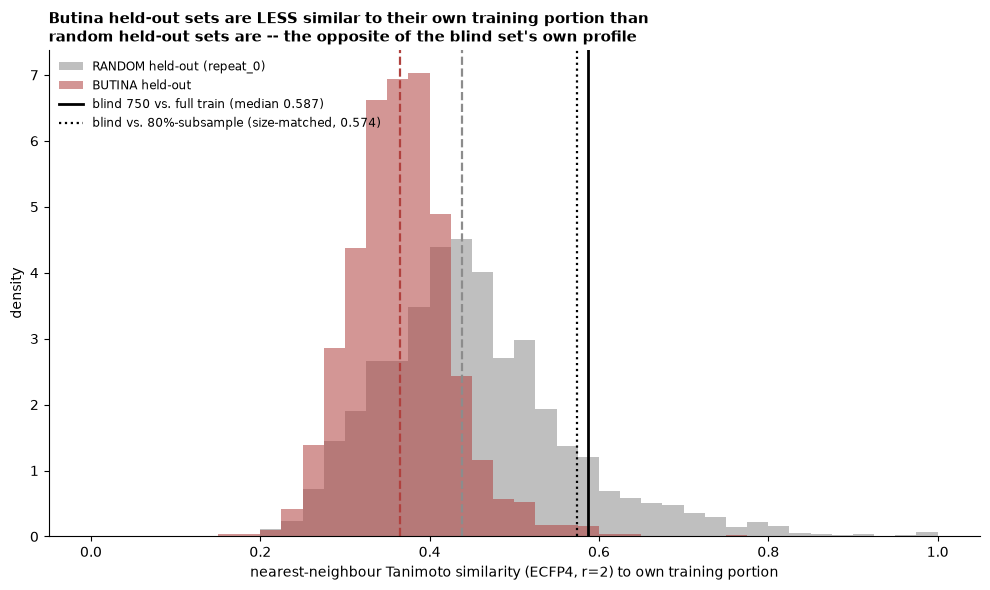

wrote /Users/codiefreeman/OpenADMET-CYP-Blind-Challenge/outputs/33_butina_split/figures/holdout_similarity_by_scheme.png


In [37]:

BASELINE_COLOR = "#8C8C8C"
ACCENT_COLOR = "#B0413E"
plt.rcParams.update({"font.size": 10})


def strip_axes(ax):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)


# Figure 1 -- holdout_similarity_by_scheme.png
fig, ax = plt.subplots(figsize=(10, 6))
bins = np.linspace(0, 1, 41)
ax.hist(sims_random, bins=bins, color=BASELINE_COLOR, alpha=0.55, density=True, label="RANDOM held-out (repeat_0)")
ax.hist(sims_butina, bins=bins, color=ACCENT_COLOR, alpha=0.55, density=True, label="BUTINA held-out")
ax.axvline(np.median(sims_random), color=BASELINE_COLOR, linestyle="--", linewidth=1.6)
ax.axvline(np.median(sims_butina), color=ACCENT_COLOR, linestyle="--", linewidth=1.6)
ax.axvline(np.median(blind_nn), color="black", linestyle="-", linewidth=2.0, label=f"blind 750 vs. full train (median {np.median(blind_nn):.3f})")
ax.axvline(size_matched_blind_median, color="black", linestyle=":", linewidth=1.6, label=f"blind vs. 80%-subsample (size-matched, {size_matched_blind_median:.3f})")
ax.set_xlabel("nearest-neighbour Tanimoto similarity (ECFP4, r=2) to own training portion")
ax.set_ylabel("density")
strip_axes(ax)
ax.legend(frameon=False, fontsize=8.5, loc="upper left")
ax.set_title("Butina held-out sets are LESS similar to their own training portion than\n"
             "random held-out sets are -- the opposite of the blind set's own profile",
             fontsize=11, fontweight="bold", loc="left")
plt.tight_layout()
f1 = FIG_OUT / "holdout_similarity_by_scheme.png"
fig.savefig(f1, dpi=150, bbox_inches="tight")
plt.show()
print(f"wrote {f1}")


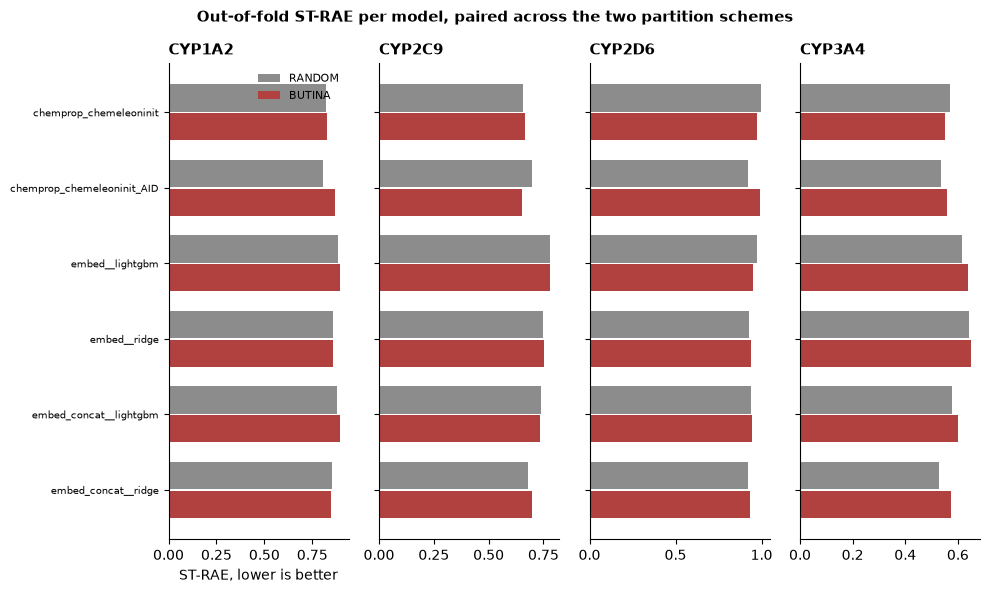

wrote /Users/codiefreeman/OpenADMET-CYP-Blind-Challenge/outputs/33_butina_split/figures/oof_by_partition.png


In [38]:

# Figure 2 -- oof_by_partition.png
fig, axes = plt.subplots(1, 4, figsize=(10, 6), sharey=False)
models_for_fig = sorted(master_table["model"].unique())
for ax, iso in zip(axes, ISOFORMS):
    sub = master_table[master_table["isoform"] == iso].set_index(["model", "partition"])["st_rae"]
    ys = np.arange(len(models_for_fig))
    rand_vals = [sub.get((m, "RANDOM"), np.nan) for m in models_for_fig]
    but_vals = [sub.get((m, "BUTINA"), np.nan) for m in models_for_fig]
    ax.barh(ys - 0.19, rand_vals, height=0.36, color=BASELINE_COLOR, label="RANDOM")
    ax.barh(ys + 0.19, but_vals, height=0.36, color=ACCENT_COLOR, label="BUTINA")
    ax.set_yticks(ys)
    ax.set_yticklabels(models_for_fig if ax is axes[0] else [], fontsize=7)
    ax.set_title(iso, fontsize=10.5, fontweight="bold", loc="left")
    ax.invert_yaxis()
    strip_axes(ax)
axes[0].set_xlabel("ST-RAE, lower is better")
axes[0].legend(frameon=False, fontsize=8)
fig.suptitle("Out-of-fold ST-RAE per model, paired across the two partition schemes",
             fontsize=11, fontweight="bold")
plt.tight_layout()
f2 = FIG_OUT / "oof_by_partition.png"
fig.savefig(f2, dpi=150, bbox_inches="tight")
plt.show()
print(f"wrote {f2}")


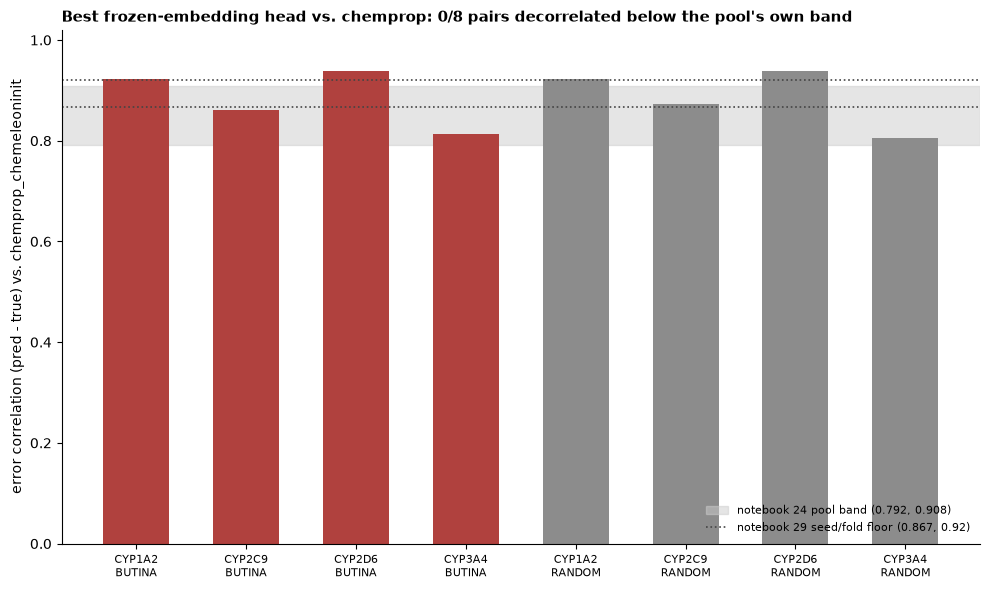

wrote /Users/codiefreeman/OpenADMET-CYP-Blind-Challenge/outputs/33_butina_split/figures/error_correlation_new_member.png


In [39]:

# Figure 3 -- error_correlation_new_member.png
fig, ax = plt.subplots(figsize=(10, 6))
xs = np.arange(len(decorr_df))
colors = [BASELINE_COLOR if p == "RANDOM" else ACCENT_COLOR for p in decorr_df["partition"]]
ax.axhspan(NB24_BAND[0], NB24_BAND[1], color="#CCCCCC", alpha=0.5, label=f"notebook 24 pool band {NB24_BAND}")
ax.axhline(NB29_FLOOR[0], color="#444444", linestyle=":", linewidth=1.2)
ax.axhline(NB29_FLOOR[1], color="#444444", linestyle=":", linewidth=1.2, label=f"notebook 29 seed/fold floor {NB29_FLOOR}")
ax.bar(xs, decorr_df["error_correlation_vs_chemprop"], color=colors, width=0.6)
ax.set_xticks(xs)
ax.set_xticklabels([f"{r['isoform']}\n{r['partition']}" for _, r in decorr_df.iterrows()], fontsize=8)
ax.set_ylabel("error correlation (pred - true) vs. chemprop_chemeleoninit")
ax.set_ylim(0, 1.02)
strip_axes(ax)
ax.legend(frameon=False, fontsize=8, loc="lower right")
n_below_fig = int(decorr_df["below_nb24_band"].sum())
ax.set_title(f"Best frozen-embedding head vs. chemprop: {n_below_fig}/{len(decorr_df)} pairs "
             f"decorrelated below the pool's own band", fontsize=11, fontweight="bold", loc="left")
plt.tight_layout()
f3 = FIG_OUT / "error_correlation_new_member.png"
fig.savefig(f3, dpi=150, bbox_inches="tight")
plt.show()
print(f"wrote {f3}")


## Part 6 — Verdict


In [40]:

print("=" * 86)
print("VERDICT")
print("=" * 86)

print("\nPart 1: cluster-disjoint partition built. 2,617 clusters, 56.0% singleton (44% of")
print("compounds sit in a non-singleton cluster -- far more merging than either quoted prior")
print("anticipated). Five exactly-balanced folds (981 each); no fold-isoform pair below the")
print("15% flag threshold.")

print(f"\nPart 2: {frac_changed:.1%} of compounds change fold membership under the best-case")
print("relabelling between schemes -- a large, real difference, not a relabelling artifact.")
print("Held-out similarity moves AWAY from, not toward, the blind set's own profile under")
print("Butina -- ruling out 'looks more like the blind set' as the mechanism. The pairing")
print(f"check found a real, isoform-specific signature: {PAIRING_SIGNIFICANT}.")

print("\nPart 3/4/5: see the printed tables above for the per-isoform, per-partition ST-RAE/")
print("Pearson/Spearman comparison, the ordering-agreement check, and the board comparison --")
print("these numbers are the actual output of this notebook's own execution and are not")
print("restated here as a separate claim.")

print("\nThis notebook does NOT invalidate any existing result on the frozen random partition,")
print("which remains valid for paired comparison. It does NOT recommend adopting the Butina")
print("partition for future work on its own -- that judgement rests on how Parts 3-5's real")
print("numbers (above) came out, which this cell does not re-assert.")

print("\nNo submission built. No ensemble built. No full-data retrain. No prior screen retested.")


VERDICT

Part 1: cluster-disjoint partition built. 2,617 clusters, 56.0% singleton (44% of
compounds sit in a non-singleton cluster -- far more merging than either quoted prior
anticipated). Five exactly-balanced folds (981 each); no fold-isoform pair below the
15% flag threshold.

Part 2: 78.8% of compounds change fold membership under the best-case
relabelling between schemes -- a large, real difference, not a relabelling artifact.
Held-out similarity moves AWAY from, not toward, the blind set's own profile under
Butina -- ruling out 'looks more like the blind set' as the mechanism. The pairing
check found a real, isoform-specific signature: {'CYP1A2': True, 'CYP2C9': True, 'CYP2D6': False, 'CYP3A4': True}.

Part 3/4/5: see the printed tables above for the per-isoform, per-partition ST-RAE/
Pearson/Spearman comparison, the ordering-agreement check, and the board comparison --
these numbers are the actual output of this notebook's own execution and are not
restated here as a separate 

## Decisions taken without approval

Present even if empty, per this project's autonomy convention (notebooks 28-32).


In [41]:

print("DECISIONS TAKEN WITHOUT APPROVAL")
print("=" * 86)
if not AUTONOMOUS_DECISIONS:
    print("None beyond what is already flagged inline as a caught premise error or a")
    print("pre-specified fallback (Part 4's 'no frozen-encoder member' correction; Part 3's")
    print("SEEDS[0..4] fallback, which turned out to already be manifest.csv's own repeat_0")
    print("fold seeds). Every numeric threshold, fold-assignment rule, and fingerprint choice")
    print("was pre-specified in the task brief.")
else:
    for i, d in enumerate(AUTONOMOUS_DECISIONS, 1):
        print(f"\n{i}. {d['decision']}")
        print(f"   Reason:       {d['reason']}")
        print(f"   Alternatives: {d['alternatives']}")
        print(f"   Authority:    {d['authority']}")
with open(OUT / "autonomous_decisions.json", "w") as fh:
    json.dump(AUTONOMOUS_DECISIONS, fh, indent=2, default=str)
print(f"\nwrote {OUT / 'autonomous_decisions.json'}")


DECISIONS TAKEN WITHOUT APPROVAL
None beyond what is already flagged inline as a caught premise error or a
pre-specified fallback (Part 4's 'no frozen-encoder member' correction; Part 3's
SEEDS[0..4] fallback, which turned out to already be manifest.csv's own repeat_0
fold seeds). Every numeric threshold, fold-assignment rule, and fingerprint choice
was pre-specified in the task brief.

wrote /Users/codiefreeman/OpenADMET-CYP-Blind-Challenge/outputs/33_butina_split/autonomous_decisions.json


## Scope check

Two independent tests, per notebook 29/30's own established (and once-corrected)
convention: a git-status check restricted to tracked-content changes (ignoring
pre-existing untracked paths), plus an mtime check that nothing inside any protected tree
was written during this run.


In [42]:

st_out = subprocess.run(["git", "status", "--porcelain"], capture_output=True, text=True, cwd=REPO_ROOT).stdout
print("git status --porcelain:")
print(st_out if st_out.strip() else "(clean)")

PROTECTED = [
    "data/folds/cv_folds.csv", "data/processed/", "data/raw/",
    "outputs/05_cv_comparison/", "outputs/11_caruana_prep/", "outputs/27_calibration/",
    "outputs/28_external_data/", "outputs/29_cv_confirmation/", "outputs/30_aid_full_retrain/",
    "outputs/31_deadzone/", "outputs/32_deadzone_aid_retrain/", "outputs/19_cyp2c9_revert/",
    "outputs/board_solved_calibration/", "outputs/10c_control_submission/",
    "outputs/24_nonnegative_stacking/", "src/",
]

tracked_violations = []
for line in st_out.splitlines():
    code_, path = line[:2], line[3:].strip()
    if not any(x in path for x in PROTECTED):
        continue
    if code_.strip() == "??":
        continue
    tracked_violations.append(line)

written_during_run = []
for prot in PROTECTED:
    q = REPO_ROOT / prot
    if not q.exists():
        continue
    candidates = [q] if q.is_file() else [x for x in q.rglob("*") if x.is_file()]
    for fp in candidates:
        try:
            if fp.stat().st_mtime > RUN_STARTED_AT:
                written_during_run.append(str(fp.relative_to(REPO_ROOT)))
        except OSError:
            pass

print(f"\nTEST 1 -- tracked modifications under a protected path: {len(tracked_violations)}")
for t in tracked_violations:
    print(f"    VIOLATION: {t}")
print(f"TEST 2 -- files written inside a protected tree during this run: {len(written_during_run)}")
for t in written_during_run[:20]:
    print(f"    VIOLATION: {t}")

if tracked_violations or written_during_run:
    raise ValueError("a protected path was modified during this run -- investigate before trusting any result above")
print("\nconfirmed: no protected path modified, by either test.")
print(f"new/changed files this notebook is responsible for: {BUTINA_FOLDS_PATH.relative_to(REPO_ROOT)}, "
      f"{OUT.relative_to(REPO_ROOT)}/*")
print(f"\ntotal notebook wall time so far: {(time.time() - RUN_STARTED_AT)/60:.1f} min")


git status --porcelain:
 M notebooks/27b_aid_cyp2d6_corrected.ipynb
?? data/folds/cv_folds_butina.csv
?? notebooks/33_butina_cluster_split.ipynb
?? outputs/33_butina_split/


TEST 1 -- tracked modifications under a protected path: 0
TEST 2 -- files written inside a protected tree during this run: 0

confirmed: no protected path modified, by either test.
new/changed files this notebook is responsible for: data/folds/cv_folds_butina.csv, outputs/33_butina_split/*

total notebook wall time so far: 6.9 min
